# Thermal paddy: leaf-grouped CV with thermal descriptor (GLCM)
**Run order:** cells 1 → 11 top to bottom (cell 12 after training).
**No feature extraction:** uses your existing `MyDrive/paddy_results/thermal_features.csv` and `temperature_maps.npz`.
**After a disconnect:** run cells 1–8, then cell 9 (it resumes), then 10–12.

## Cell 1 – SETUP (mount Drive, results helper)

In [1]:
# ============================================================
# CELL 1: SETUP - mount Drive + results helper (run first, every session)
# Every figure/number for the paper is produced by save_results()
# from model predictions -- no hand-typed values anywhere.
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                             accuracy_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

RESULTS_DIR = '/content/drive/MyDrive/paddy_results'
os.makedirs(RESULTS_DIR, exist_ok=True)


def save_results(tag, title, y_true, y_prob, class_names, hist,
                 finetune_epoch=None, train_acc=None):
    """Save CM, class-wise bars, curves, per-class ROC, CSV/JSON and raw
    predictions for one model. All outputs come from the same predictions."""
    out = os.path.join(RESULTS_DIR, tag)
    os.makedirs(out, exist_ok=True)
    class_names = [str(c) for c in class_names]
    n = len(class_names)
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = y_prob.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    correct = int((y_true == y_pred).sum())
    p, r, f, s = precision_recall_fscore_support(
        y_true, y_pred, labels=range(n), zero_division=0)

    # 1. Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(n))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{out}/confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 2. Class-wise precision / recall / F1
    x = np.arange(n); w = 0.25
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for k, (vals, lab) in enumerate([(p, 'Precision'), (r, 'Recall'), (f, 'F1-Score')]):
        bars = ax.bar(x + (k - 1) * w, vals, w, label=lab)
        for b in bars:
            ax.annotate(f'{b.get_height():.3f}', (b.get_x() + b.get_width() / 2, b.get_height()),
                        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylim(0, 1.08); ax.set_xlabel('Class'); ax.set_ylabel('Score')
    ax.set_title(f'Class-wise Precision, Recall & F1-Score - {title}')
    ax.legend(loc='lower right'); ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(f'{out}/classwise_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 3. Training curves (epochs numbered from 1)
    ep = np.arange(1, len(hist['accuracy']) + 1)
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
    for a, k, lab in [(axs[0], 'accuracy', 'Accuracy'), (axs[1], 'loss', 'Loss')]:
        a.plot(ep, hist[k], label=f'Training {lab}')
        a.plot(ep, hist['val_' + k], label=f'Validation {lab}')
        if finetune_epoch:
            a.axvline(finetune_epoch, color='green', linestyle='--', label='Fine-tuning starts')
        a.set_xlabel('Epoch'); a.set_ylabel(lab); a.set_title(f'{title}: {lab}')
        a.grid(alpha=0.3); a.legend()
    plt.tight_layout()
    plt.savefig(f'{out}/train_val_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 4. Per-class ROC (one-vs-rest, from predicted probabilities)
    yb = label_binarize(y_true, classes=range(n))
    aucs = {}
    plt.figure(figsize=(7, 6))
    for i, c in enumerate(class_names):
        if yb[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(yb[:, i], y_prob[:, i])
        aucs[c] = float(auc(fpr, tpr))
        plt.plot(fpr, tpr, label=f'{c} (AUC = {aucs[c]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC - {title}'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{out}/roc.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 5. Tables + raw predictions (needed later for DSI and Table 4)
    pd.DataFrame({'Class': class_names, 'Precision': p, 'Recall': r, 'F1': f,
                  'Support': s, 'AUC': [aucs.get(c, np.nan) for c in class_names]}
                 ).to_csv(f'{out}/per_class_metrics.csv', index=False)
    pd.DataFrame(hist).to_csv(f'{out}/history.csv', index_label='epoch0')
    np.savez(f'{out}/predictions.npz', y_true=y_true, y_prob=y_prob,
             class_names=np.array(class_names))
    summary = {'model': title, 'test_acc': float(acc), 'correct': correct,
               'n_test': int(len(y_true)), 'train_acc': train_acc,
               'support': {c: int(v) for c, v in zip(class_names, s)},
               'epochs_run': int(len(ep))}
    json.dump(summary, open(f'{out}/summary.json', 'w'), indent=2)

    print(f'\n{title}: test acc = {acc:.4f} ({correct}/{len(y_true)})'
          + (f' | train acc = {train_acc:.4f}' if train_acc is not None else ''))
    print('Test support per class:', summary['support'])
    print('Saved to', out)
    return summary


Mounted at /content/drive


## Cell 2 – Imports and settings
Edit `SESSION`, `BACKBONES`, `BRANCHES` here.

In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 893.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 32.8 MB/s eta 0:00:00


In [3]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 17.3 MB/s eta 0:00:00


In [4]:
# CELL 2: IMPORTS + SETTINGS
import os, shutil, numpy as np, pandas as pd, cv2, tensorflow as tf
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import binomtest
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Layer, Conv2D
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications import vgg16, resnet50
from tensorflow.keras.utils import Sequence

# -------------------- CONFIG --------------------
DATA_ROOT  = '/content/drive/MyDrive/paddy_diseases'
FEAT_CSV   = '/content/drive/MyDrive/paddy_results/thermal_features.csv'
MAPS_NPZ   = '/content/drive/MyDrive/paddy_results/temperature_maps.npz'
SESSION    = '2020:01:27'         # None = all 636 images
N_FOLDS    = 5                        # grouped folds; every image is tested exactly once
BACKBONES  = ['vgg16', 'resnet50', 'deform_resnet50']
BRANCHES   = ['none', 'descriptor']   # options: 'none', 'features', 'glcm', 'descriptor', 'encoder'
IMG_SIZE   = (224, 224)
BS         = 16
EPOCHS_1, LR_1 = 15, 1e-3         # stage 1: backbone frozen
EPOCHS_2, LR_2 = 30, 1e-5         # stage 2: last block fine-tuned
# within-leaf features only; absolute temperature (T_mean/median/min/max) excluded
THERMAL_FEATS = ['T_std', 'MTD', 'MTD_robust', 'T_iqr', 'T_skew', 'T_kurt',
                 'hot_frac', 'cold_frac', 'grad_mean']
NAMES = {'vgg16': 'VGG16', 'resnet50': 'ResNet50', 'deform_resnet50': 'Deform-ResNet50'}
BR_NAME = {'none': '', 'features': ' + Thermal features', 'glcm': ' + GLCM',
           'descriptor': ' + Thermal descriptor', 'encoder': ' + Thermal encoder'}
VEC_BRANCHES = ('features', 'glcm', 'descriptor')     # branches that feed a feature vector
TAG = lambda b, br: f'{b}' + ('' if br == 'none' else f'_{br}')


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## Cell 3 – Deformable convolution layer

In [5]:
# CELL 3: DEFORMABLE CONVOLUTION (Eq. 4)
# -------------------- DEFORMABLE CONV (Eq. 4) --------------------

class DeformConv2D(Layer):
    """Deformable 3x3 convolution (Dai et al., 2017): learnable per-position
    offsets, bilinear sampling, then a standard weighted sum (Eq. 4)."""
    def __init__(self, filters, kernel_size=3, max_offset=2.0, **kwargs):
        super().__init__(**kwargs)
        self.filters, self.k, self.max_offset = filters, kernel_size, max_offset

    def build(self, input_shape):
        k, C = self.k, int(input_shape[-1])
        self.K, self.C = k * k, C
        r = tf.range(k, dtype=tf.float32) - (k - 1) / 2.0
        gy, gx = tf.meshgrid(r, r, indexing='ij')
        self.ky = tf.reshape(gy, [1, 1, 1, -1])          # kernel grid P_k
        self.kx = tf.reshape(gx, [1, 1, 1, -1])
        # offsets Delta P_k, zero-initialised -> starts as a regular conv
        self.offset_conv = Conv2D(2 * self.K, k, padding='same',
                                  kernel_initializer='zeros', bias_initializer='zeros',
                                  name=self.name + '_offset')
        self.offset_conv.build(input_shape)
        self.kernel = self.add_weight(name='kernel', shape=(self.K * C, self.filters),
                                      initializer='glorot_uniform', trainable=True)
        self.bias = self.add_weight(name='bias', shape=(self.filters,),
                                    initializer='zeros', trainable=True)
        super().build(input_shape)

    def _bilinear(self, img, y, x):
        s = tf.shape(img); B, H, W = s[0], s[1], s[2]
        Hf, Wf = tf.cast(H, tf.float32), tf.cast(W, tf.float32)
        y = tf.clip_by_value(y, 0.0, Hf - 1.0); x = tf.clip_by_value(x, 0.0, Wf - 1.0)
        y0, x0 = tf.floor(y), tf.floor(x)
        y1, x1 = tf.minimum(y0 + 1.0, Hf - 1.0), tf.minimum(x0 + 1.0, Wf - 1.0)
        wy, wx = (y - y0)[..., None], (x - x0)[..., None]
        b = tf.broadcast_to(tf.reshape(tf.range(B), [-1, 1, 1, 1]), tf.shape(y))
        def g(yy, xx):
            idx = tf.stack([b, tf.cast(yy, tf.int32), tf.cast(xx, tf.int32)], axis=-1)
            return tf.gather_nd(img, idx)                 # (B,H,W,K,C)
        return ((1 - wy) * (1 - wx) * g(y0, x0) + (1 - wy) * wx * g(y0, x1)
                + wy * (1 - wx) * g(y1, x0) + wy * wx * g(y1, x1))

    def call(self, inputs):
        off = self.offset_conv(inputs)                    # (B,H,W,2K)
        off = 0.1 * off + tf.stop_gradient(0.9 * off)     # 0.1x learning rate on offsets
        off = self.max_offset * tf.tanh(off / self.max_offset)   # bounded offsets (px)
        s = tf.shape(inputs); B, H, W = s[0], s[1], s[2]
        ii = tf.reshape(tf.cast(tf.range(H), tf.float32), [1, -1, 1, 1])
        jj = tf.reshape(tf.cast(tf.range(W), tf.float32), [1, 1, -1, 1])
        y = ii + self.ky + off[..., :self.K]
        x = jj + self.kx + off[..., self.K:]
        cols = tf.reshape(self._bilinear(inputs, y, x), [B, H, W, self.K * self.C])
        return tf.tensordot(cols, self.kernel, axes=[[3], [0]]) + self.bias

    def get_config(self):
        cfg = super().get_config(); cfg.update(filters=self.filters, kernel_size=self.k, max_offset=self.max_offset); return cfg


## Cell 4 – Load images + your existing thermal_features.csv and temperature_maps.npz
No feature extraction: uses the two files already in `MyDrive/paddy_results/`. Prints the group table.

In [6]:
# CELL 4: LOAD DATA (uses existing thermal_features.csv + temperature_maps.npz)
# -------------------- DATA (copied to the Colab disk once per session: much faster) --------------------
for src, dst in [(DATA_ROOT, '/content/paddy_diseases'), (MAPS_NPZ, '/content/temperature_maps.npz')]:
    if not os.path.exists(dst):
        (shutil.copytree if os.path.isdir(src) else shutil.copy)(src, dst)
DATA_ROOT, MAPS_NPZ = '/content/paddy_diseases', '/content/temperature_maps.npz'
tdf = pd.read_csv(FEAT_CSV)
maps = np.load(MAPS_NPZ)
map_key = {os.path.join(*k.split('__')[-2:]): k for k in maps.files}   # 'class/file.jpg' -> npz key
key = lambda cls, f: os.path.join(cls, os.path.basename(f))
feat_of = {key(r['class'], r['file']): r for _, r in tdf.iterrows()}

imgs, feats, tmaps, labels, paths = [], [], [], [], []
for plant in sorted(d for d in os.listdir(DATA_ROOT) if not d.startswith('.')):
    plant_dir = os.path.join(DATA_ROOT, plant)
    if not os.path.isdir(plant_dir):
        continue
    for cls in sorted(d for d in os.listdir(plant_dir) if not d.startswith('.')):
        cdir = os.path.join(plant_dir, cls)
        if not os.path.isdir(cdir):
            continue
        for f in sorted(os.listdir(cdir)):
            if not f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                continue
            r = feat_of.get(key(cls, f))
            if r is None:
                print('  no thermal features, skipped:', key(cls, f)); continue
            if SESSION and r['date'] != SESSION:
                continue
            if key(cls, f) not in map_key:
                print('  no temperature map, skipped:', key(cls, f)); continue
            bgr = cv2.imread(os.path.join(cdir, f))
            if bgr is None:
                continue
            imgs.append(cv2.cvtColor(cv2.resize(bgr, IMG_SIZE), cv2.COLOR_BGR2RGB).astype(np.float32))
            feats.append([r[c] for c in THERMAL_FEATS])
            T = cv2.resize(maps[map_key[key(cls, f)]].astype(np.float32), IMG_SIZE)
            tmaps.append(T - T.mean())                 # deg C relative to the image mean
            labels.append(cls); paths.append(key(cls, f))
X, Fe, paths = np.array(imgs), np.array(feats, dtype=np.float32), np.array(paths)
TM = np.array(tmaps, dtype=np.float32)[..., None]                # (N,224,224,1)
lb = LabelBinarizer(); Y = lb.fit_transform(labels); y_int = Y.argmax(1)
import re
def leaf_group(p):                                   # 'BLB/thermalimage73b.jpg' -> 'BLB_73'
    cls, f = os.path.split(p)
    m = re.search(r'thermalimage(\d+)', f, flags=re.I)
    return f'{cls}_{m.group(1)}' if m else p         # unmatched names: own group
groups = np.array([leaf_group(p) for p in paths])
class_names = [str(c) for c in lb.classes_]
OUT_DIR = (f'{RESULTS_DIR}/grouped_session_{SESSION[5:7]}{SESSION[8:10]}' if SESSION
           else f'{RESULTS_DIR}/grouped_full')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'{"Session " + SESSION if SESSION else "Full dataset"}: {len(X)} images',
      {c: int(n) for c, n in zip(class_names, np.bincount(y_int))})

gdf = pd.DataFrame({'class': labels, 'group': groups})
gtab = gdf.groupby('class').agg(images=('group', 'size'), groups=('group', 'nunique'))
gtab['largest_group'] = gdf.groupby(['class', 'group']).size().groupby('class').max()
print(gtab); gtab.to_csv(f'{OUT_DIR}/groups_per_class.csv')
few = gtab.index[gtab['groups'] < N_FOLDS].tolist()
if few:
    print(f'NOTE: {few} have fewer than {N_FOLDS} leaf groups -> tested in only some folds; '
          'every fold still trains on all classes.')

Session 2020:01:27: 315 images {'BLB': 97, 'Blast': 39, 'healthy': 93, 'hispa': 25, 'leaf spot': 61}
           images  groups  largest_group
class                                   
BLB            97      45              9
Blast          39       3             22
healthy        93       9             51
hispa          25      13              7
leaf spot      61      31              6
NOTE: ['Blast'] have fewer than 5 leaf groups -> tested in only some folds; every fold still trains on all classes.


## Cell 5 – Leaf-grouped folds
Check: Blast in ~3 folds; same fold lines as earlier runs.

In [7]:
# CELL 5: LEAF-GROUPED FOLDS
def balanced_group_folds(y, groups, k, seed=42):
    """Assign whole leaf groups to k folds, class by class, largest groups first, each to
    the fold holding the fewest images of that class. Spreads a class's groups across folds,
    so no class ends up entirely in one test fold (unlike StratifiedGroupKFold here)."""
    rng = np.random.default_rng(seed)
    fold_of, load = {}, np.zeros((k, int(y.max()) + 1))
    for c in np.unique(y):
        gs = list(np.unique(groups[y == c])); rng.shuffle(gs)
        size = {g: int(np.sum(groups == g)) for g in gs}
        for g in sorted(gs, key=lambda g: -size[g]):           # random tie-break kept
            f = int(np.argmin(load[:, c] + 1e-3 * load.sum(1)))
            fold_of[g] = f; load[f, c] += size[g]
    return np.array([fold_of[g] for g in groups])

FOLDS = []                                           # (train, val, test) indices per fold
fold_id = balanced_group_folds(y_int, groups, N_FOLDS)
for k in range(N_FOLDS):
    te, trv = np.where(fold_id == k)[0], np.where(fold_id != k)[0]
    # validation: ~1/8 of groups, only from classes with >= 4 groups left (rare classes stay in train)
    ok = np.array([len(np.unique(groups[trv][y_int[trv] == c])) >= 4 for c in y_int[trv]])
    va_mask = np.zeros(len(trv), bool)
    if ok.any():
        inner = balanced_group_folds(y_int[trv][ok], groups[trv][ok], 8, seed=k)
        va_mask[np.where(ok)[0][inner == 0]] = True
    tr, va = trv[~va_mask], trv[va_mask]
    assert not (set(groups[tr]) & set(groups[te])) and not (set(groups[va]) & set(groups[te]))
    assert set(y_int[tr]) == set(y_int), f'fold {k}: a class is missing from training'
    FOLDS.append((tr, va, te))
    cnt = lambda ix: {c: int(n) for c, n in zip(class_names, np.bincount(y_int[ix], minlength=len(class_names)))}
    print(f'Fold {k}: train {len(tr)} | val {len(va)} | test {len(te)} | test per class', cnt(te))
pd.DataFrame({'file': paths, 'group': groups,
              'fold': np.concatenate([[k] * len(f[2]) for k, f in enumerate(FOLDS)])[
                  np.argsort(np.concatenate([f[2] for f in FOLDS]))]}).to_csv(f'{OUT_DIR}/folds.csv', index=False)


Fold 0: train 206 | val 22 | test 87 | test per class {'BLB': 20, 'Blast': 0, 'healthy': 51, 'hispa': 4, 'leaf spot': 12}
Fold 1: train 235 | val 22 | test 58 | test per class {'BLB': 20, 'Blast': 0, 'healthy': 21, 'hispa': 5, 'leaf spot': 12}
Fold 2: train 227 | val 24 | test 64 | test per class {'BLB': 19, 'Blast': 22, 'healthy': 7, 'hispa': 4, 'leaf spot': 12}
Fold 3: train 232 | val 24 | test 59 | test per class {'BLB': 19, 'Blast': 16, 'healthy': 7, 'hispa': 5, 'leaf spot': 12}
Fold 4: train 245 | val 23 | test 47 | test per class {'BLB': 19, 'Blast': 1, 'healthy': 7, 'hispa': 7, 'leaf spot': 13}


## Cell 6 – GLCM + thermal descriptor
Should print `GLCM features: (315, 18) | descriptor: (315, 27)`.

In [8]:
# CELL 6: GLCM + THERMAL DESCRIPTOR
# -------------------- GLCM texture of the temperature map --------------------
# deg C relative to the image mean, FIXED range (-3..+3 deg C) -> 32 grey levels, so a
# level means the same temperature difference in every image (no per-image rescaling)
from skimage.feature import graycomatrix, graycoprops
GLCM_RANGE, GLCM_LEVELS, GLCM_DIST = 3.0, 32, [1, 2, 4]
GLCM_PROPS = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
def glcm_features(tmap):
    q = np.clip((tmap + GLCM_RANGE) / (2 * GLCM_RANGE), 0, 1 - 1e-6)
    q = (q * GLCM_LEVELS).astype(np.uint8)
    P = graycomatrix(q, distances=GLCM_DIST, angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
                     levels=GLCM_LEVELS, symmetric=True, normed=True)
    return np.concatenate([graycoprops(P, p).mean(axis=1) for p in GLCM_PROPS])   # 6 x 3 = 18
G = np.array([glcm_features(t[..., 0]) for t in TM], dtype=np.float32)
G = np.nan_to_num(G)                                  # correlation is NaN on a perfectly flat map
FEATS = {'features': Fe, 'glcm': G, 'descriptor': np.concatenate([Fe, G], axis=1)}
print('GLCM features:', G.shape, '| descriptor:', FEATS['descriptor'].shape)
F_s = np.zeros_like(Fe)                              # set per fold (scaler fit on that fold's train)


GLCM features: (315, 18) | descriptor: (315, 27)


## Cell 7 – Data generator and models

In [9]:
# CELL 7: DATA GENERATOR + MODELS
class Gen(Sequence):
    def __init__(self, ids, prep, branch, augment=False, shuffle=False):
        super().__init__(workers=4 if augment else 1, max_queue_size=16)   # parallel loading
        self.ids, self.prep, self.branch = np.array(ids), prep, branch
        self.aug, self.shuffle = augment, shuffle
        self.on_epoch_end()
    def __len__(self):
        return int(np.ceil(len(self.ids) / BS))
    def __getitem__(self, i):
        b = self.ids[i * BS:(i + 1) * BS]
        im, tm = X[b].copy(), TM[b].copy()
        if self.aug:       # geometric only (colours encode temperature); SAME transform on both
            for j in range(len(im)):
                if np.random.rand() < 0.5: im[j], tm[j] = im[j][:, ::-1], tm[j][:, ::-1]
                if np.random.rand() < 0.5: im[j], tm[j] = im[j][::-1, :], tm[j][::-1, :]
                ang, sc = np.random.uniform(-15, 15), np.random.uniform(0.9, 1.1)
                M = cv2.getRotationMatrix2D((IMG_SIZE[0] / 2, IMG_SIZE[1] / 2), ang, sc)
                im[j] = cv2.warpAffine(im[j], M, IMG_SIZE, borderMode=cv2.BORDER_REFLECT)
                tm[j] = cv2.warpAffine(tm[j], M, IMG_SIZE, borderMode=cv2.BORDER_REFLECT)[..., None]
        im = self.prep(im)
        if self.branch == 'encoder':
            inp = (im, tm)
        elif self.branch in VEC_BRANCHES:
            inp = (im, F_s[b])
        else:
            inp = im
        return inp, Y[b].astype(np.float32)
    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.ids)

# -------------------- MODELS --------------------
def thermal_encoder(t_in):
    t = t_in
    for filters in [16, 32, 64, 64, 64]:                                # 224 -> 7
        t = layers.Conv2D(filters, 3, strides=2, padding='same', use_bias=False)(t)
        t = layers.BatchNormalization()(t); t = layers.Activation('relu')(t)
    return layers.SpatialDropout2D(0.2, name='thermal_map')(t)          # 7x7x64

def build_model(backbone, branch):
    if backbone == 'vgg16':
        base = VGG16(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
        prep, last_block = vgg16.preprocess_input, 'block5'
    else:
        base = ResNet50(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
        prep, last_block = resnet50.preprocess_input, 'conv5_block3'
    base.trainable = False
    img_in = layers.Input((*IMG_SIZE, 3), name='image')
    f = base(img_in, training=False)                                    # 7x7xC
    f = layers.Conv2D(128, 1, use_bias=False)(f)
    f = layers.BatchNormalization()(f)
    f = layers.Activation('relu', name='reduce')(f)
    inputs = img_in
    if branch == 'encoder':
        t_in = layers.Input((*IMG_SIZE, 1), name='temperature')
        f = layers.Concatenate(name='fused_map')([f, thermal_encoder(t_in)])   # 7x7x320
        inputs = [img_in, t_in]
    if backbone == 'deform_resnet50':
        f = DeformConv2D(128, 3, name='deform')(f)                      # deformable 3x3
    else:
        f = layers.Conv2D(128, 3, padding='same', name='conv3x3')(f)    # standard 3x3
    f = layers.BatchNormalization()(f); f = layers.Activation('relu')(f)
    f = layers.GlobalAveragePooling2D()(f)                              # 512-D
    if branch in VEC_BRANCHES:
        t_in = layers.Input((F_s.shape[1],), name='thermal')
        t = layers.GaussianNoise(0.1)(t_in)
        t = layers.Dense(16, activation='relu',
                         kernel_regularizer=tf.keras.regularizers.l2(1e-3))(t)
        t = layers.Dropout(0.5)(t)
        f = layers.Concatenate()([f, t])                                # 528-D fusion
        inputs = [img_in, t_in]
    out = layers.Dense(len(class_names), activation='softmax')(layers.Dropout(0.5)(f))
    return Model(inputs, out), base, prep, last_block

def compile_(m, lr):
    m.compile(optimizer=tf.keras.optimizers.AdamW(lr, weight_decay=1e-4),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

def predict(m, gen, tta=True):
    p, t = [], []
    for i in range(len(gen)):
        xb, yb = gen[i]
        im, rest = (xb[0], xb[1:]) if isinstance(xb, tuple) else (xb, ())
        flips = [lambda a: a, lambda a: a[:, :, ::-1], lambda a: a[:, ::-1, :]] if tta else [lambda a: a]
        outs = []
        for fl in flips:      # flip image and temperature map together; feature vectors unchanged
            r = tuple(fl(x) if np.ndim(x) == 4 else x for x in rest)
            outs.append(np.asarray(m.predict_on_batch((fl(im), *r) if r else fl(im))))
        p.append(np.mean(outs, 0))
        t.append(yb.argmax(1))
    return np.vstack(p), np.concatenate(t)


## Cell 8 – Resumable training functions

In [10]:
# CELL 8: RESUMABLE TRAINING FUNCTIONS
# -------------------- RESUMABLE TRAINING --------------------
# All progress is written to Drive after EVERY epoch. If Colab disconnects, re-run
# SETUP + this cell: finished runs are skipped, an unfinished run continues from its
# last completed epoch (weights, learning rate, early-stopping counters, history).
import json, shutil, warnings
warnings.filterwarnings('ignore', message='Skipping variable loading for optimizer')  # optimizer moments restart on resume; weights do load
from sklearn.metrics import f1_score
STATE_ROOT = f'{OUT_DIR}/_resume'
os.makedirs(STATE_ROOT, exist_ok=True)

def _save_weights_atomic(model, path):           # a disconnect mid-write can't corrupt the file
    tmp = path.replace('.weights.h5', '.tmp.weights.h5')
    model.save_weights(tmp)
    os.replace(tmp, path)

def _write_json(path, obj):                       # atomic write: never leaves a half file
    tmp = path + '.tmp'
    with open(tmp, 'w') as fh: json.dump(obj, fh)
    os.replace(tmp, path)

class ResumableStage(tf.keras.callbacks.Callback):
    """Best-on-val checkpoint + early stopping + LR halving, with all state on Drive."""
    def __init__(self, sdir, lr0, patience, lr_patience=3, min_lr=1e-7):
        super().__init__()
        self.sdir, self.patience, self.lr_patience, self.min_lr = sdir, patience, lr_patience, min_lr
        os.makedirs(sdir, exist_ok=True)
        self.state_path = f'{sdir}/state.json'
        self.best_w, self.last_w = f'{sdir}/best.weights.h5', f'{sdir}/last.weights.h5'
        self.state = (json.load(open(self.state_path)) if os.path.exists(self.state_path) else
                      {'epoch': -1, 'best': float('inf'), 'wait': 0, 'lr_wait': 0, 'lr': lr0,
                       'done': False, 'history': {k: [] for k in
                                                  ['accuracy', 'val_accuracy', 'loss', 'val_loss']}})
    def on_epoch_end(self, epoch, logs=None):
        st = self.state
        for k in st['history']:
            st['history'][k].append(float(logs[k]))
        if logs['val_loss'] < st['best']:
            st['best'], st['wait'], st['lr_wait'] = float(logs['val_loss']), 0, 0
            _save_weights_atomic(self.model, self.best_w)
        else:
            st['wait'] += 1; st['lr_wait'] += 1
            if st['lr_wait'] >= self.lr_patience and st['lr'] > self.min_lr:
                st['lr'], st['lr_wait'] = max(st['lr'] * 0.5, self.min_lr), 0
                self.model.optimizer.learning_rate.assign(st['lr'])
        st['epoch'] = epoch
        if st['wait'] >= self.patience:
            self.model.stop_training = True
        _save_weights_atomic(self.model, self.last_w)
        _write_json(self.state_path, st)
    def on_train_end(self, logs=None):
        self.state['done'] = True
        _write_json(self.state_path, self.state)

def run_stage(model, sdir, lr0, epochs, patience, tr, va, start_weights=None):
    cb = ResumableStage(sdir, lr0, patience)
    st = cb.state
    if not st['done']:
        compile_(model, st['lr'])
        if st['epoch'] >= 0:                                   # resume mid-stage
            try:
                model.load_weights(cb.last_w)
                print(f'    resuming {os.path.basename(sdir)} at epoch {st["epoch"] + 2}')
            except Exception:                                  # damaged checkpoint: restart this stage
                print(f'    checkpoint in {sdir} unreadable -> restarting this stage from scratch')
                shutil.rmtree(sdir, ignore_errors=True)
                return run_stage(model, sdir, lr0, epochs, patience, tr, va, start_weights)
        if st['epoch'] < 0 and start_weights:
            model.load_weights(start_weights)
        if st['epoch'] + 1 < epochs:
            model.fit(tr, validation_data=va, epochs=epochs, initial_epoch=st['epoch'] + 1,
                      class_weight=class_weight, callbacks=[cb], verbose=0)
        else:
            cb.on_train_end()
    else:
        compile_(model, st['lr'])
    model.load_weights(cb.best_w)                              # best epoch on VALIDATION loss
    return cb.state['history'], cb.best_w


## Cell 9 – TRAIN (long: ~4–6 h)
If Colab disconnects: run cells 1–8 again, then this cell. Finished folds are reused; the unfinished one resumes.

VGG16                                fold 0: done earlier (test 0.9770)
VGG16                                fold 1: done earlier (test 0.9138)
VGG16                                fold 2: done earlier (test 0.9531)
VGG16                                fold 3: done earlier (test 0.8136)
VGG16                                fold 4: done earlier (test 0.8298)


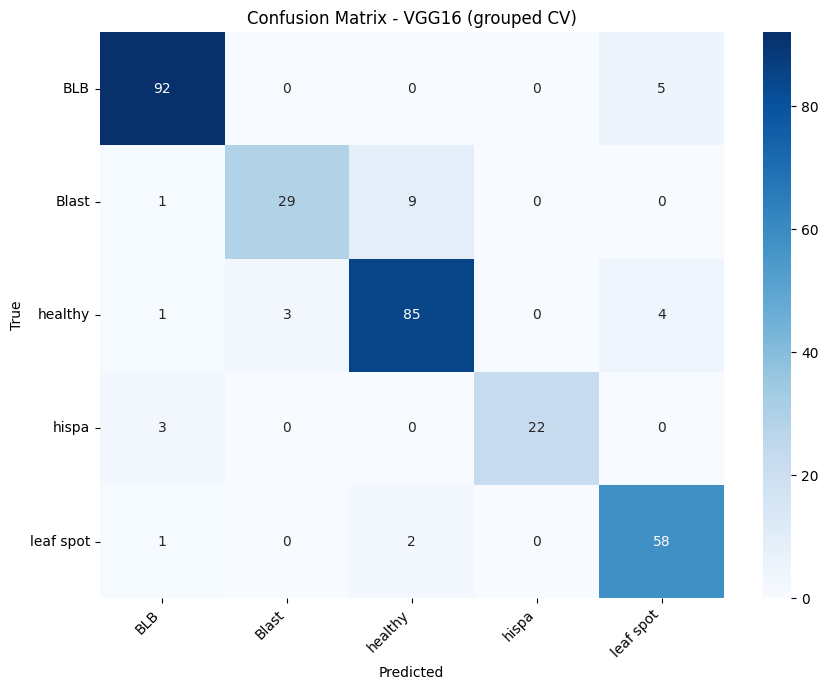

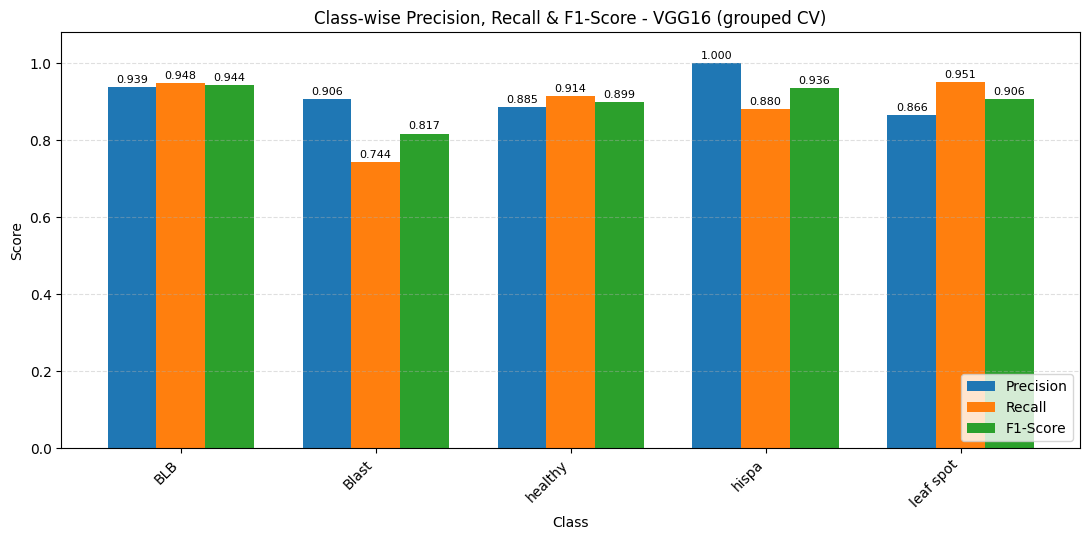

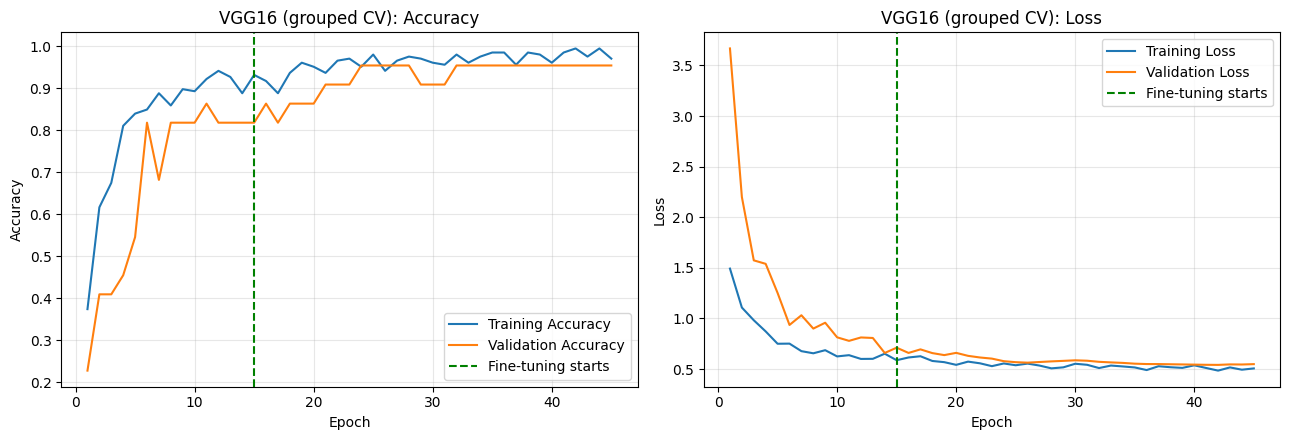

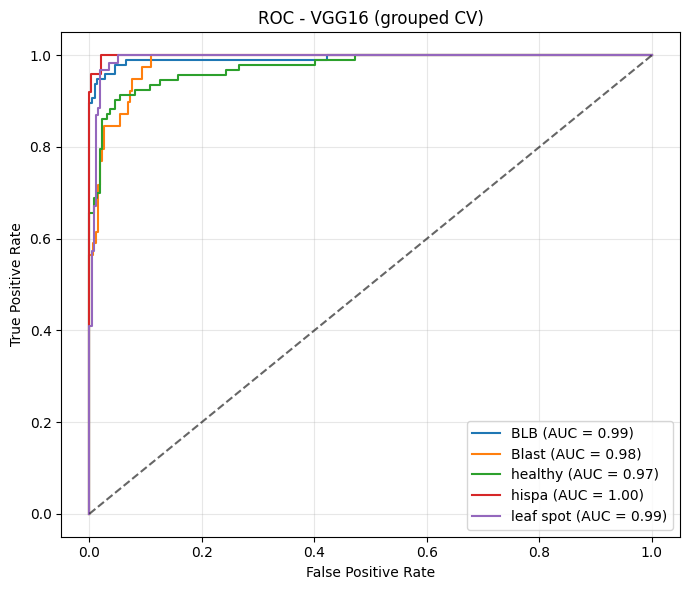


VGG16 (grouped CV): test acc = 0.9079 (286/315) | train acc = 0.9931
Test support per class: {'BLB': 97, 'Blast': 39, 'healthy': 93, 'hispa': 25, 'leaf spot': 61}
Saved to /content/drive/MyDrive/paddy_results/grouped_session_0127/vgg16
VGG16 + Thermal descriptor           fold 0: done earlier (test 0.9655)
VGG16 + Thermal descriptor           fold 1: done earlier (test 0.9483)
VGG16 + Thermal descriptor           fold 2: done earlier (test 0.8906)
VGG16 + Thermal descriptor           fold 3: done earlier (test 0.8305)
VGG16 + Thermal descriptor           fold 4: done earlier (test 0.8511)


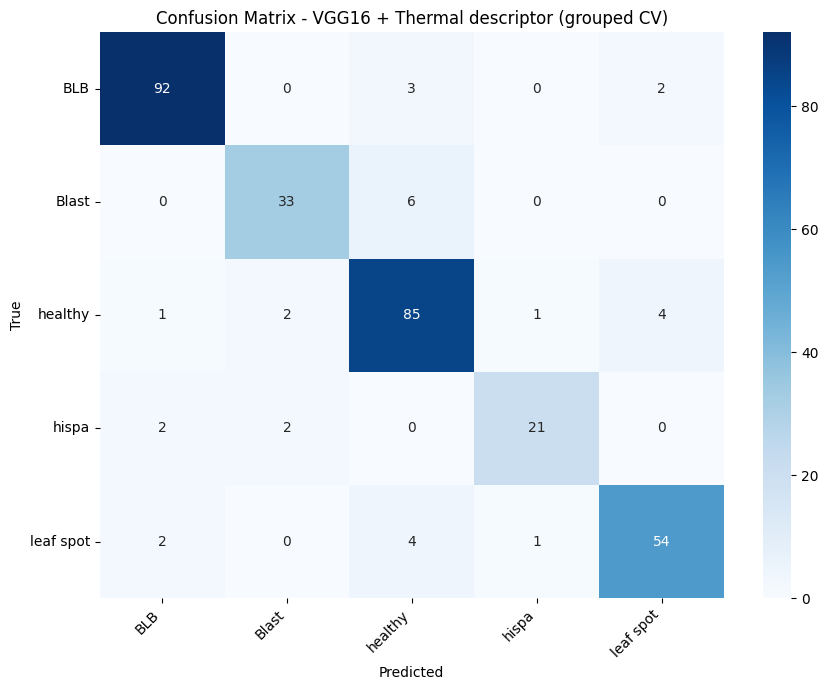

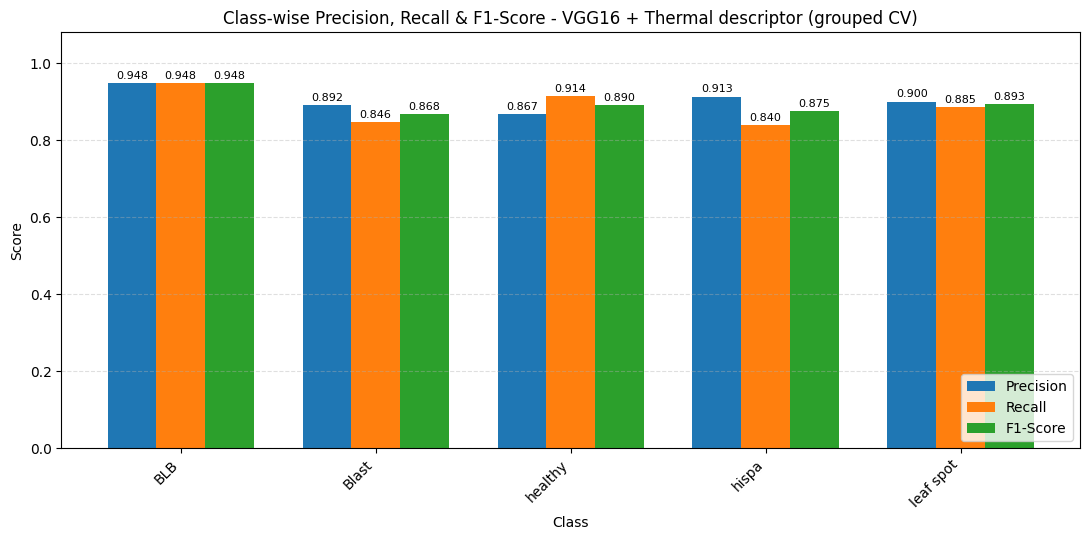

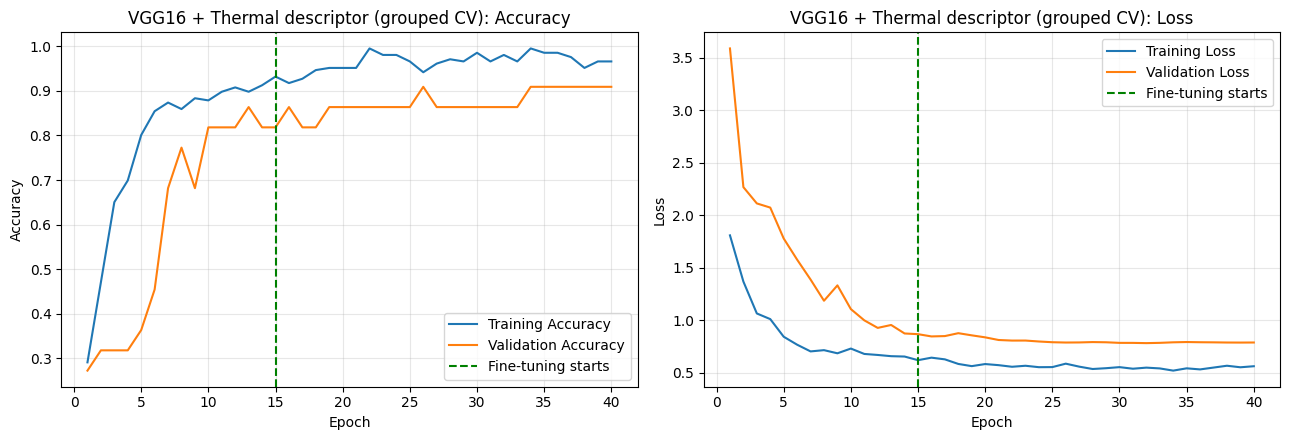

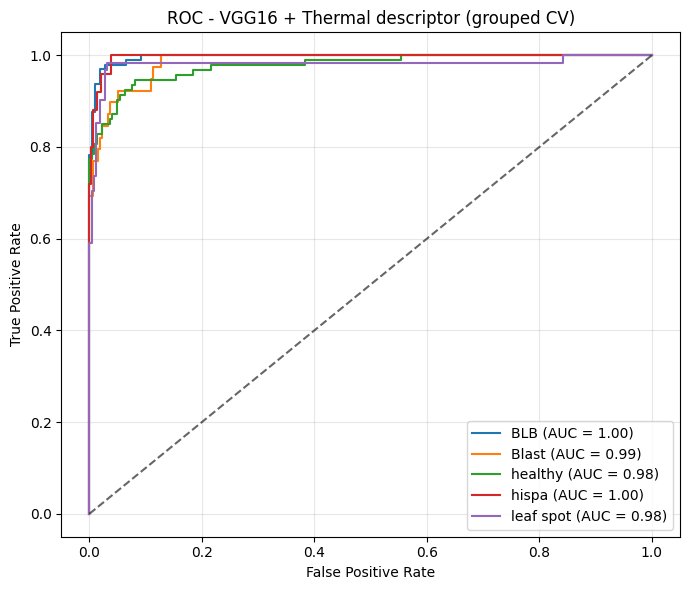


VGG16 + Thermal descriptor (grouped CV): test acc = 0.9048 (285/315) | train acc = 0.9947
Test support per class: {'BLB': 97, 'Blast': 39, 'healthy': 93, 'hispa': 25, 'leaf spot': 61}
Saved to /content/drive/MyDrive/paddy_results/grouped_session_0127/vgg16_descriptor
ResNet50                             fold 0: done earlier (test 0.9080)
    resuming stage2 at epoch 12
ResNet50                             fold 1: test 0.9655 | train 1.0000
ResNet50                             fold 2: test 0.9062 | train 0.9824
ResNet50                             fold 3: test 0.7458 | train 0.9914
ResNet50                             fold 4: test 0.8085 | train 0.9918


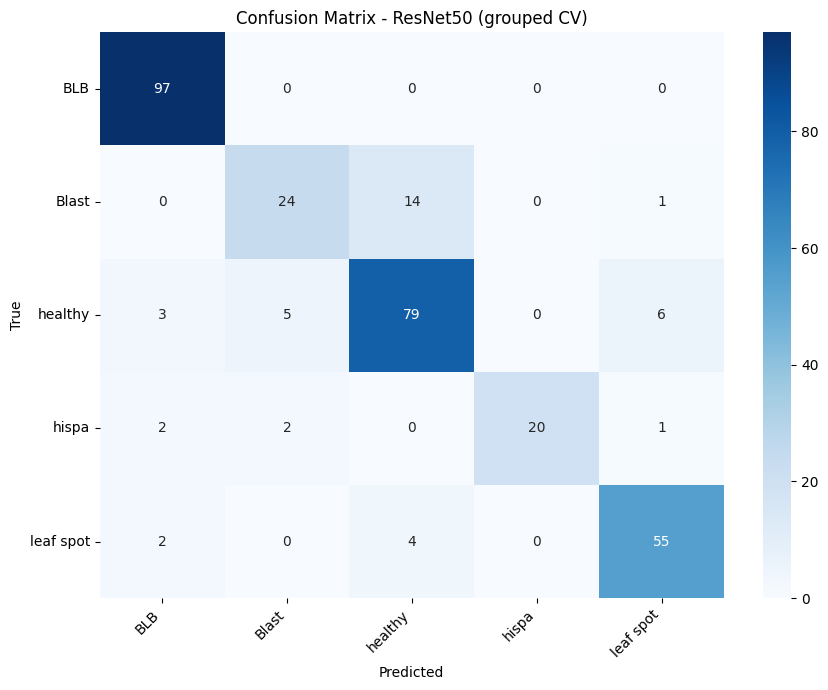

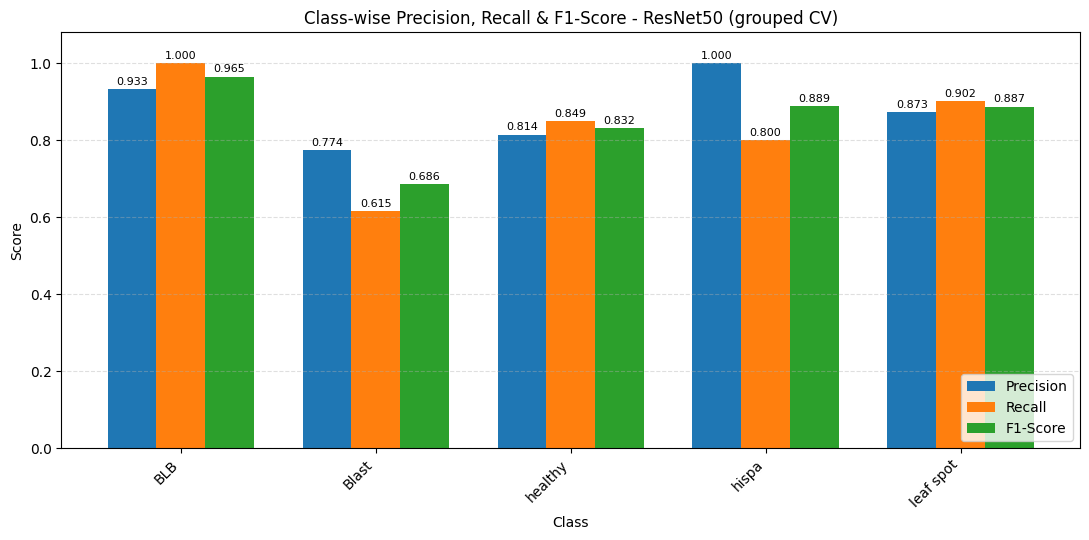

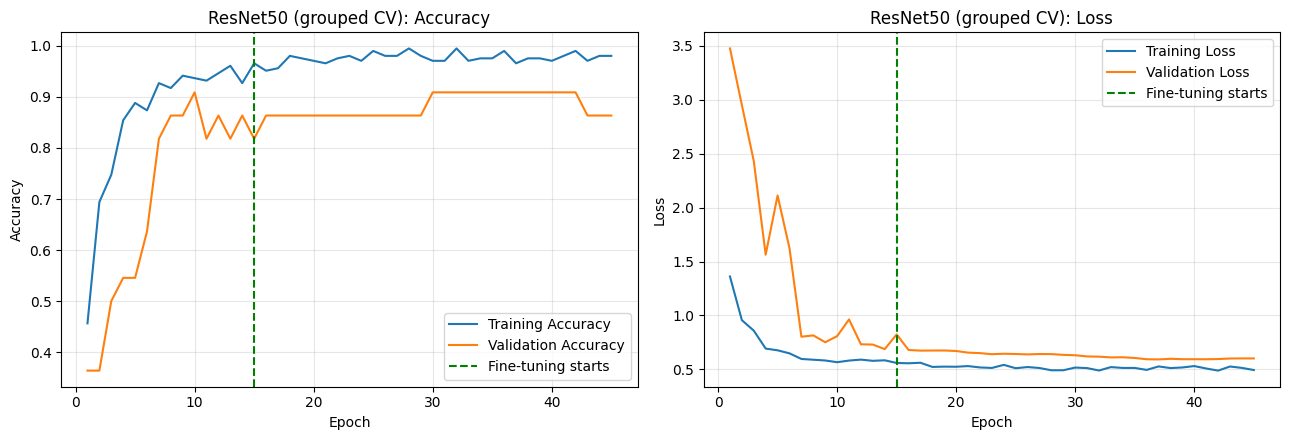

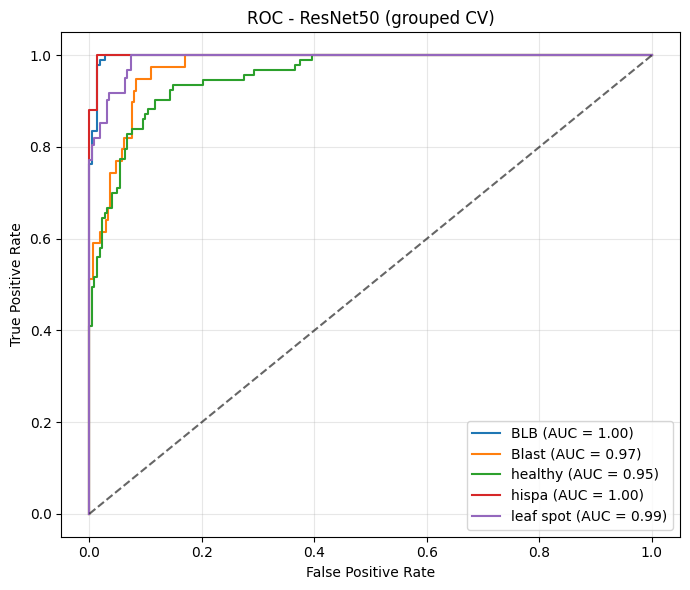


ResNet50 (grouped CV): test acc = 0.8730 (275/315) | train acc = 0.9931
Test support per class: {'BLB': 97, 'Blast': 39, 'healthy': 93, 'hispa': 25, 'leaf spot': 61}
Saved to /content/drive/MyDrive/paddy_results/grouped_session_0127/resnet50
ResNet50 + Thermal descriptor        fold 0: test 0.9080 | train 0.9951
ResNet50 + Thermal descriptor        fold 1: test 0.9655 | train 1.0000
ResNet50 + Thermal descriptor        fold 2: test 0.9375 | train 0.9780
ResNet50 + Thermal descriptor        fold 3: test 0.8136 | train 0.9138
ResNet50 + Thermal descriptor        fold 4: test 0.7660 | train 0.9878


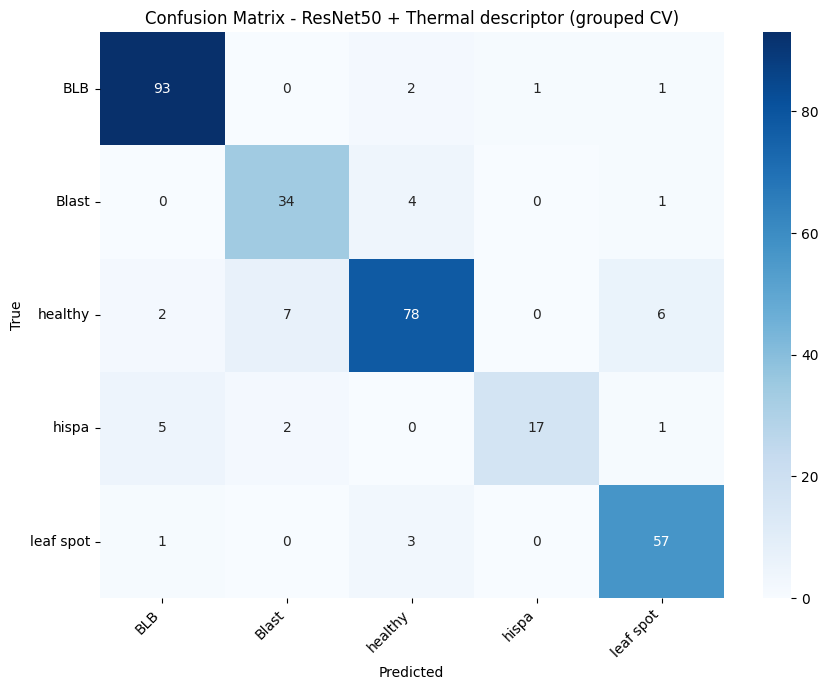

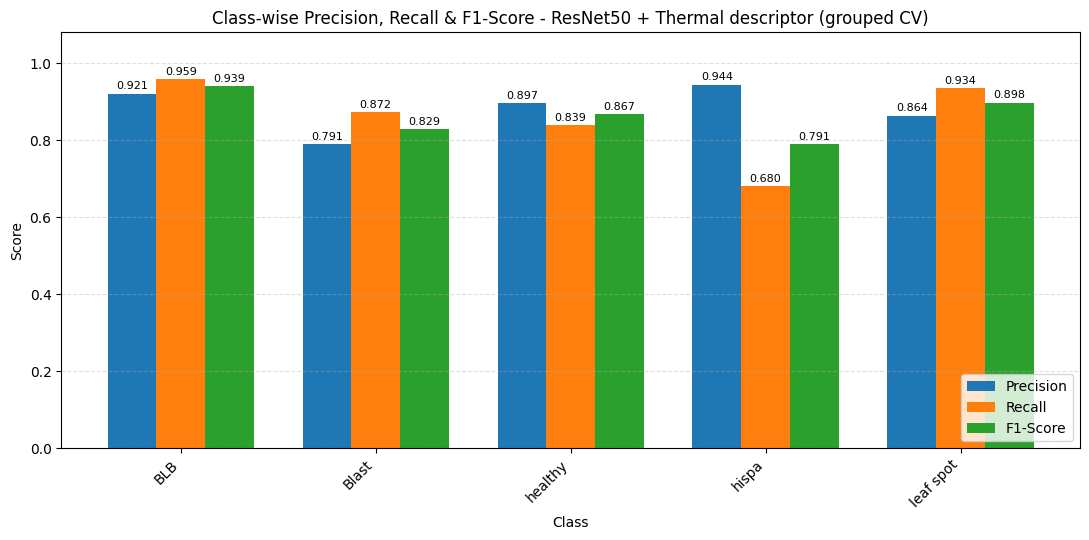

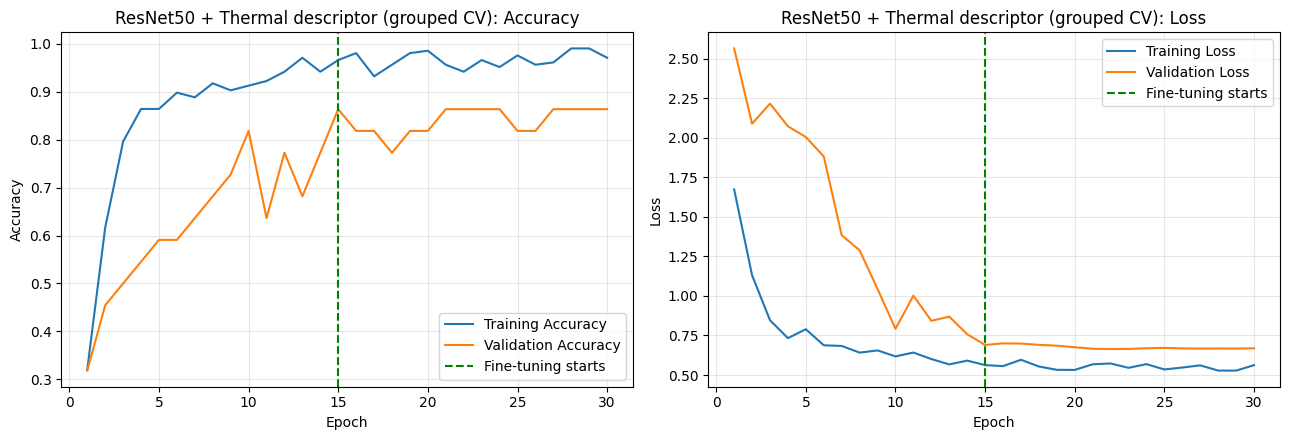

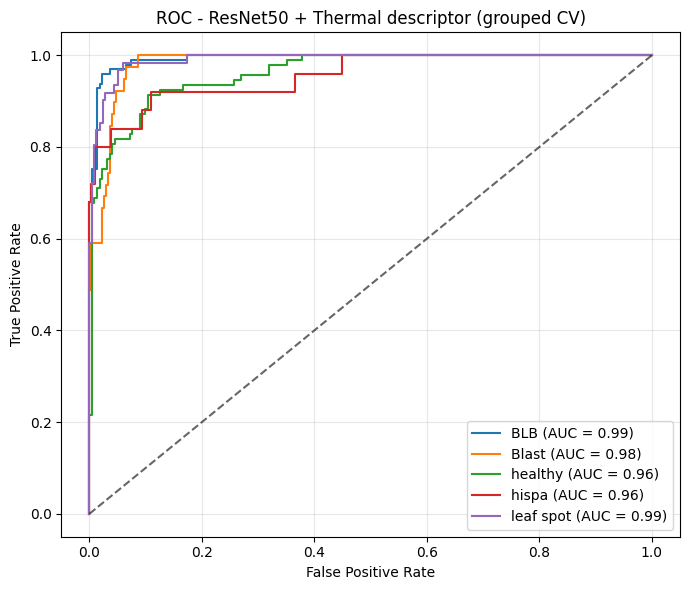


ResNet50 + Thermal descriptor (grouped CV): test acc = 0.8857 (279/315) | train acc = 0.9749
Test support per class: {'BLB': 97, 'Blast': 39, 'healthy': 93, 'hispa': 25, 'leaf spot': 61}
Saved to /content/drive/MyDrive/paddy_results/grouped_session_0127/resnet50_descriptor
Deform-ResNet50                      fold 0: test 0.9310 | train 0.9951
Deform-ResNet50                      fold 1: test 0.9138 | train 0.9660
Deform-ResNet50                      fold 2: test 0.7031 | train 0.8458
Deform-ResNet50                      fold 3: test 0.7288 | train 1.0000
Deform-ResNet50                      fold 4: test 0.7660 | train 0.9878


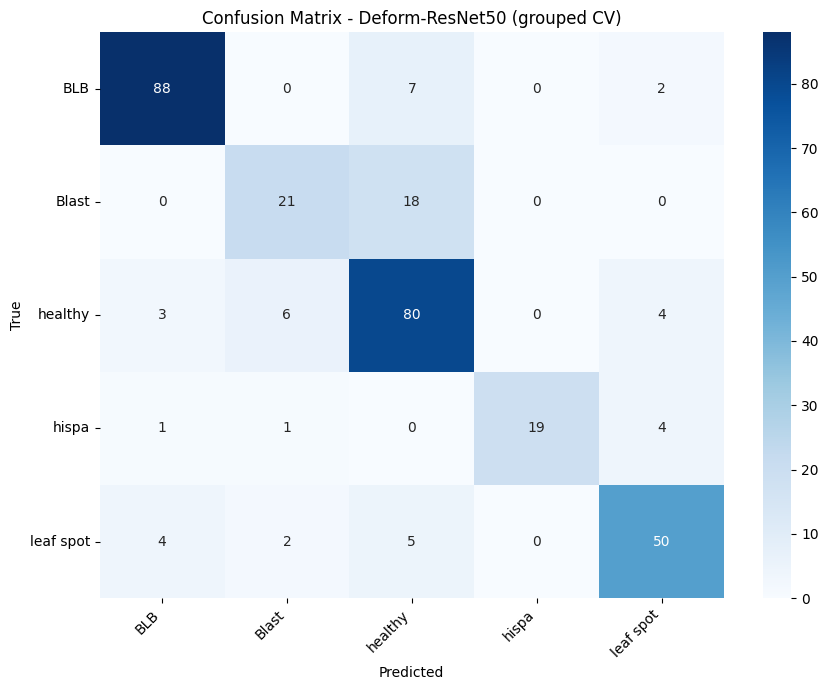

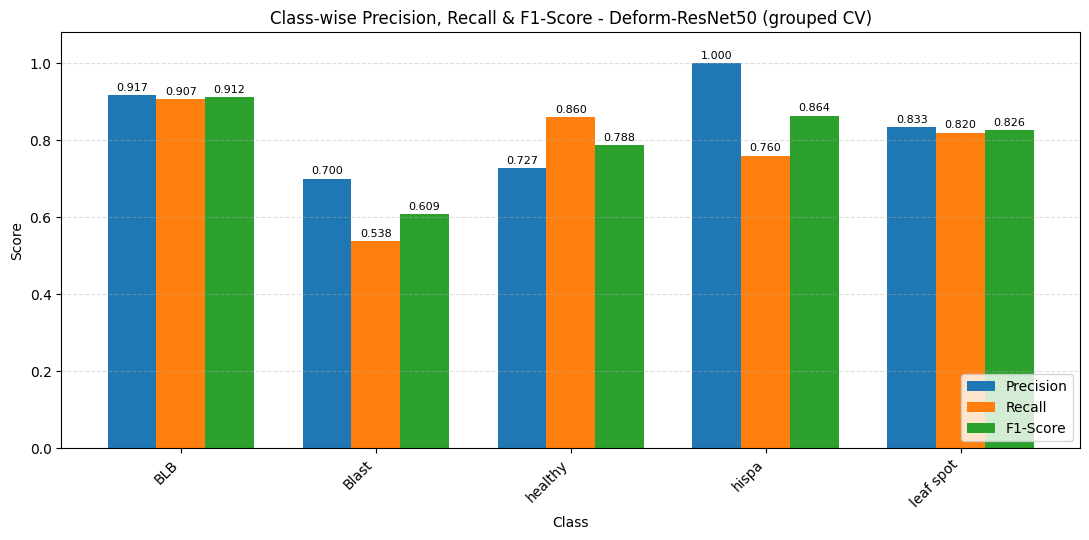

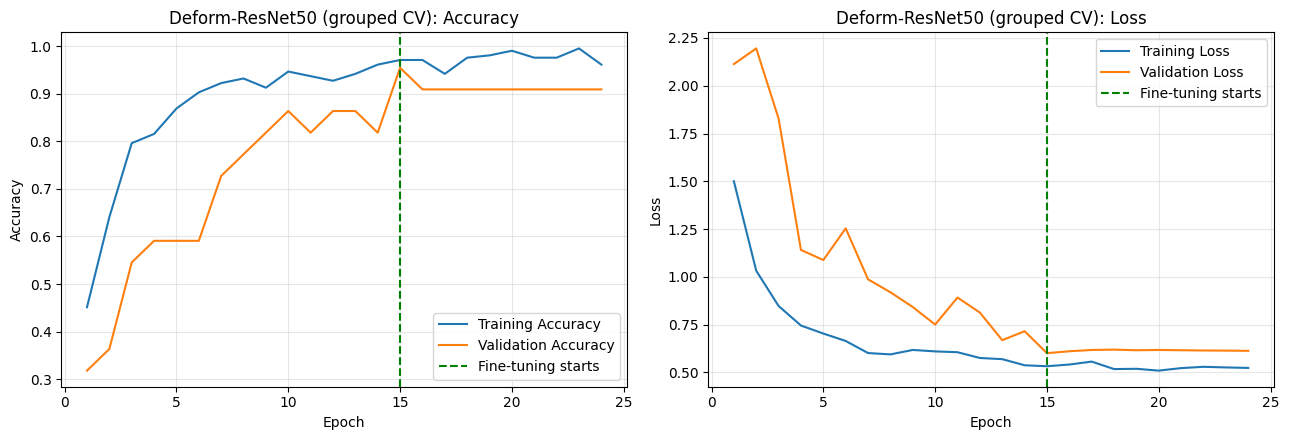

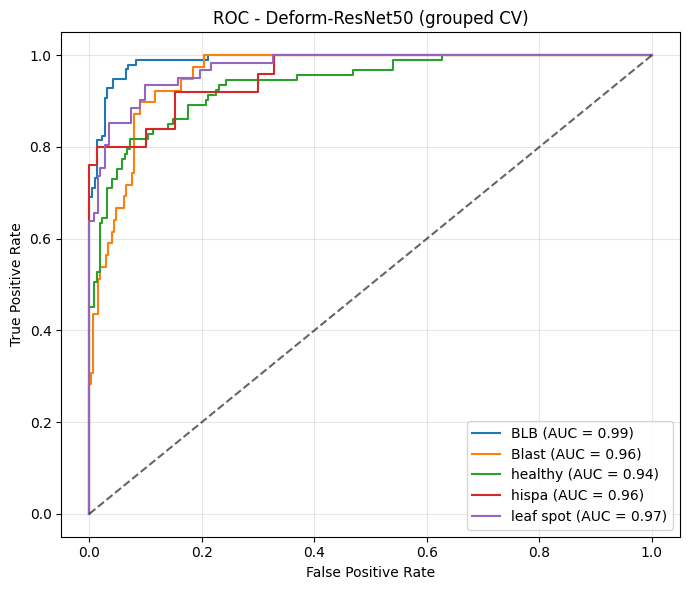


Deform-ResNet50 (grouped CV): test acc = 0.8190 (258/315) | train acc = 0.9589
Test support per class: {'BLB': 97, 'Blast': 39, 'healthy': 93, 'hispa': 25, 'leaf spot': 61}
Saved to /content/drive/MyDrive/paddy_results/grouped_session_0127/deform_resnet50
Deform-ResNet50 + Thermal descriptor fold 0: test 0.9310 | train 0.9903
Deform-ResNet50 + Thermal descriptor fold 1: test 0.9483 | train 0.9957
Deform-ResNet50 + Thermal descriptor fold 2: test 0.9219 | train 0.9912
Deform-ResNet50 + Thermal descriptor fold 3: test 0.7288 | train 1.0000
Deform-ResNet50 + Thermal descriptor fold 4: test 0.7660 | train 0.9755


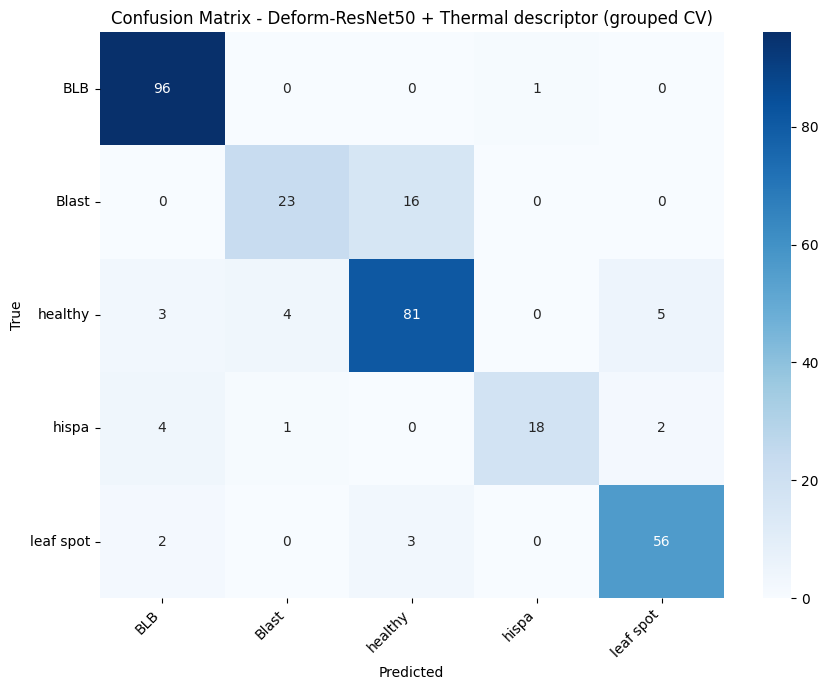

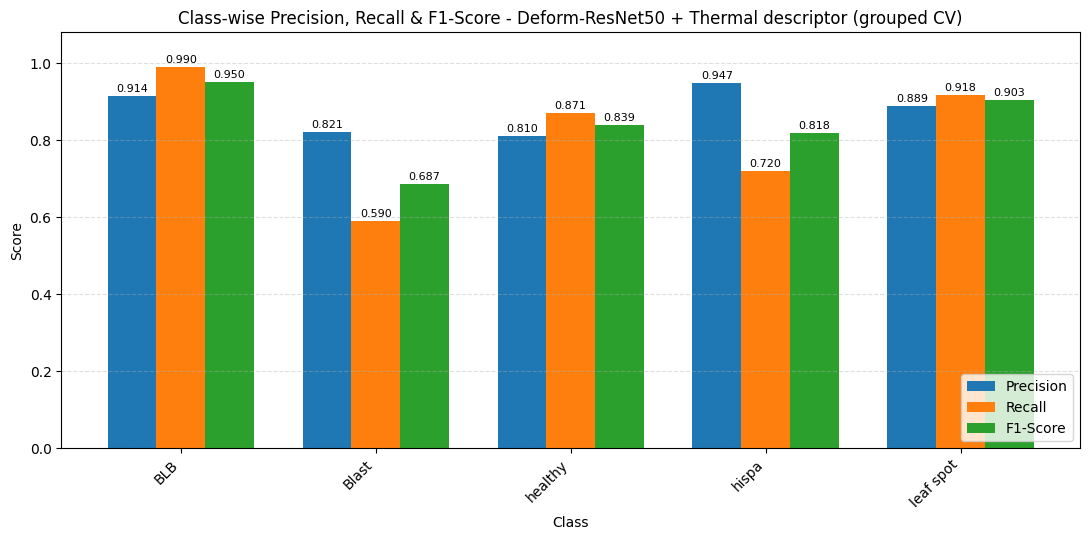

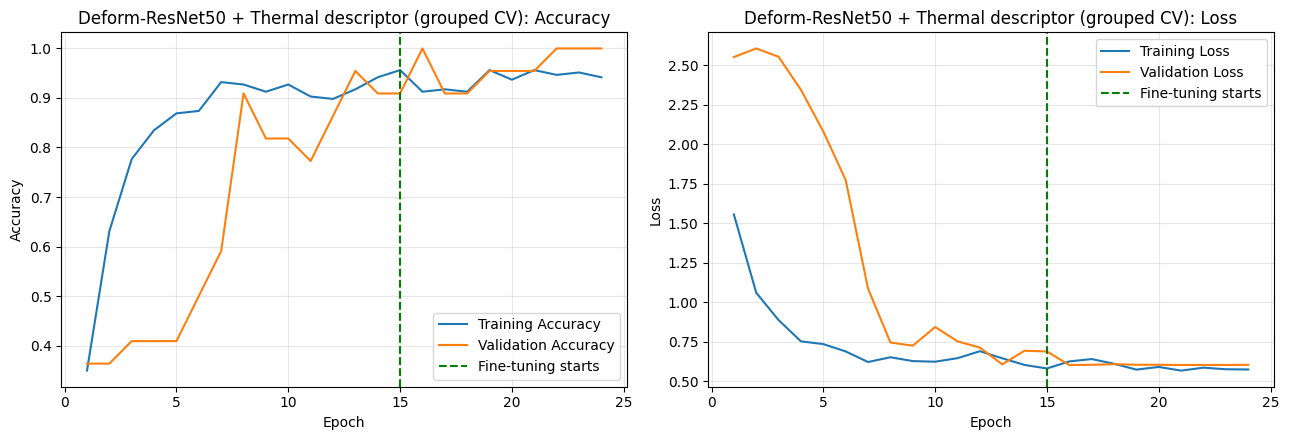

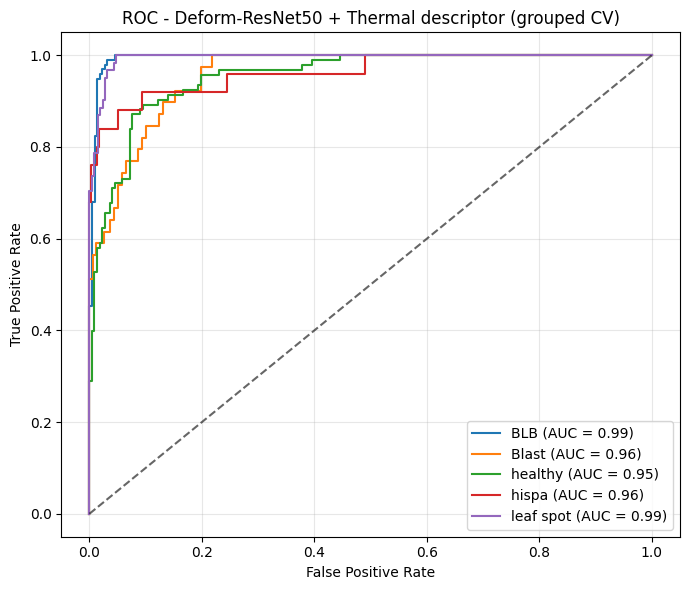


Deform-ResNet50 + Thermal descriptor (grouped CV): test acc = 0.8698 (274/315) | train acc = 0.9905
Test support per class: {'BLB': 97, 'Blast': 39, 'healthy': 93, 'hispa': 25, 'leaf spot': 61}
Saved to /content/drive/MyDrive/paddy_results/grouped_session_0127/deform_resnet50_descriptor


In [32]:
# CELL 9: TRAIN ALL MODELS x FOLDS (resumable)
_save_dir = RESULTS_DIR
runs, correct_vec, f1_rows = [], {}, []
for backbone in BACKBONES:
    for branch in BRANCHES:
        tag = TAG(backbone, branch)
        title = NAMES[backbone] + BR_NAME[branch]
        oof_prob = np.zeros((len(y_int), len(class_names)), np.float32); hist0, ft0 = None, None
        for si, seed in enumerate(range(N_FOLDS)):          # 'seed' = fold index
            tr_idx, va_idx, te_idx = FOLDS[seed]
            Fb = FEATS.get(branch, Fe)
            F_s = StandardScaler().fit(Fb[tr_idx]).transform(Fb).astype(np.float32)
            present = np.unique(y_int[tr_idx])
            class_weight = {i: 1.0 for i in range(len(class_names))}
            class_weight.update({int(i): float(w) for i, w in zip(present,
                                 compute_class_weight('balanced', classes=present, y=y_int[tr_idx]))})
            rdir = f'{STATE_ROOT}/{tag}_fold{seed}'
            done_file = f'{rdir}/result.json'
            if os.path.exists(done_file):                      # finished earlier: reuse
                res = json.load(open(done_file))
                runs.append(res['row']); f1_rows += res['f1']
                oof_prob[te_idx] = np.array(res['y_prob'], np.float32)
                if si == 0: hist0, ft0 = res['hist'], res['ft']
                print(f'{title:36s} fold {seed}: done earlier (test {res["row"]["test_acc"]:.4f})')
                continue

            tf.keras.backend.clear_session()
            np.random.seed(seed); tf.random.set_seed(seed)
            model, base, prep, last_block = build_model(backbone, branch)
            tr = Gen(tr_idx, prep, branch, augment=True, shuffle=True)
            va = Gen(va_idx, prep, branch)

            h1, best1 = run_stage(model, f'{rdir}/stage1', LR_1, EPOCHS_1, 6, tr, va)   # frozen
            base.trainable = True                                                        # fine-tune
            for l in base.layers:
                l.trainable = (l.name.startswith(last_block)
                               and not isinstance(l, layers.BatchNormalization))
            h2, _ = run_stage(model, f'{rdir}/stage2', LR_2, EPOCHS_2, 8, tr, va, start_weights=best1)

            hist = {k: h1[k] + h2[k] for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']}
            y_prob, y_true = predict(model, Gen(te_idx, prep, branch))
            tp, tt = predict(model, Gen(tr_idx, prep, branch), tta=False)
            fold_acc = float((y_prob.argmax(1) == y_true).mean())
            summ = {'test_acc': fold_acc, 'train_acc': float((tp.argmax(1) == tt).mean())}
            oof_prob[te_idx] = y_prob
            if si == 0: hist0, ft0 = hist, len(h1['loss'])
            correct = (y_prob.argmax(1) == y_true)
            f1 = [{'model': title, 'seed': seed, 'class': c, 'F1': float(v)} for c, v in
                  zip(class_names, f1_score(y_true, y_prob.argmax(1), labels=range(len(class_names)),
                                            average=None, zero_division=0))]
            row = {'model': title, 'backbone': backbone, 'branch': branch, 'seed': seed,
                   'test_acc': summ['test_acc'], 'train_acc': summ['train_acc']}
            if backbone == 'deform_resnet50':
                dl = model.get_layer('deform')
                fm = Model(model.inputs, dl.input)
                tg = Gen(te_idx, prep, branch)
                fmap = np.vstack([np.asarray(fm.predict_on_batch(tg[i][0])) for i in range(len(tg))])
                off = (dl.max_offset * tf.tanh(dl.offset_conv(fmap) / dl.max_offset)).numpy()
                row['mean_abs_offset'] = float(np.abs(off).mean())
            _write_json(done_file, {'row': row, 'f1': f1, 'y_prob': y_prob.tolist(),
                                    'hist': hist, 'ft': len(h1['loss'])})
            for st in ['stage1', 'stage2']:                    # free Drive space; result is saved
                for wf in ['last.weights.h5', 'best.weights.h5']:
                    p = f'{rdir}/{st}/{wf}'
                    if os.path.exists(p) and not (st == 'stage2' and wf == 'best.weights.h5'):
                        os.remove(p)
            runs.append(row); f1_rows += f1
            print(f'{title:36s} fold {seed}: test {summ["test_acc"]:.4f} | train {summ["train_acc"]:.4f}')
        # pooled out-of-fold results: every image predicted once by a model that never saw its leaf
        RESULTS_DIR = OUT_DIR
        save_results(tag, title + ' (grouped CV)', y_int, oof_prob, class_names, hist0, finetune_epoch=ft0,
                     train_acc=float(np.mean([r['train_acc'] for r in runs if r['model'] == title])))
        RESULTS_DIR = _save_dir
        correct_vec[tag] = (oof_prob.argmax(1) == y_int)


## Cell 10 – Summary table + McNemar

In [34]:
# CELL 10: SUMMARY + McNEMAR
# -------------------- SUMMARY --------------------
runs = pd.DataFrame(runs)
runs.to_csv(f'{OUT_DIR}/comparison_runs.csv', index=False)
order = [NAMES[b] + BR_NAME[br] for b in BACKBONES for br in BRANCHES]
summary = (runs.groupby('model')[['train_acc', 'test_acc']].agg(['mean', 'std']) * 100).round(2)
summary = summary.reindex([m for m in order if m in summary.index])
summary.to_csv(f'{OUT_DIR}/comparison_summary.csv')
print('\nAccuracy (%) over', N_FOLDS, 'grouped folds:'); print(summary)
if 'mean_abs_offset' in runs:
    print('\nDeformable offsets (mean |offset|, px on 7x7 map):',
          runs.dropna(subset=['mean_abs_offset']).groupby('model')['mean_abs_offset'].mean().round(3).to_dict())

# Paired exact McNemar on pooled out-of-fold predictions: each branch vs image-only
print('\nMcNemar on all images (out-of-fold), branch vs image-only:')
rows = []
for b_ in BACKBONES:
    for br in [x for x in BRANCHES if x != 'none']:
        a, t = correct_vec.get(TAG(b_, 'none')), correct_vec.get(TAG(b_, br))
        if a is None or t is None:
            continue
        only_a, only_t = int(np.sum(a & ~t)), int(np.sum(~a & t))
        p = binomtest(only_a, only_a + only_t, 0.5).pvalue if only_a + only_t else 1.0
        rows.append({'model': NAMES[b_] + BR_NAME[br], 'acc_image_only': round(a.mean(), 4),
                     'acc_with_branch': round(t.mean(), 4), 'only_image_right': only_a,
                     'only_branch_right': only_t, 'p': round(p, 4)})
mc = pd.DataFrame(rows); mc.to_csv(f'{OUT_DIR}/mcnemar.csv', index=False)
print(mc.to_string(index=False) if len(mc) else '(needs the "none" branch in BRANCHES)')



Accuracy (%) over 5 grouped folds:
                                     train_acc       test_acc       
                                          mean   std     mean    std
model                                                               
VGG16                                    99.31  0.58    89.75   7.30
VGG16 + Thermal descriptor               99.47  0.36    89.72   5.89
ResNet50                                 99.31  0.73    86.68   8.81
ResNet50 + Thermal descriptor            97.49  3.52    87.81   8.49
Deform-ResNet50                          95.89  6.46    80.85  10.65
Deform-ResNet50 + Thermal descriptor     99.05  0.93    85.92  10.33

Deformable offsets (mean |offset|, px on 7x7 map): {'Deform-ResNet50': 0.721, 'Deform-ResNet50 + Thermal descriptor': 0.785}

McNemar on all images (out-of-fold), branch vs image-only:
                               model  acc_image_only  acc_with_branch  only_image_right  only_branch_right      p
          VGG16 + Thermal descriptor       

## Cell 11 – Comparison graphs

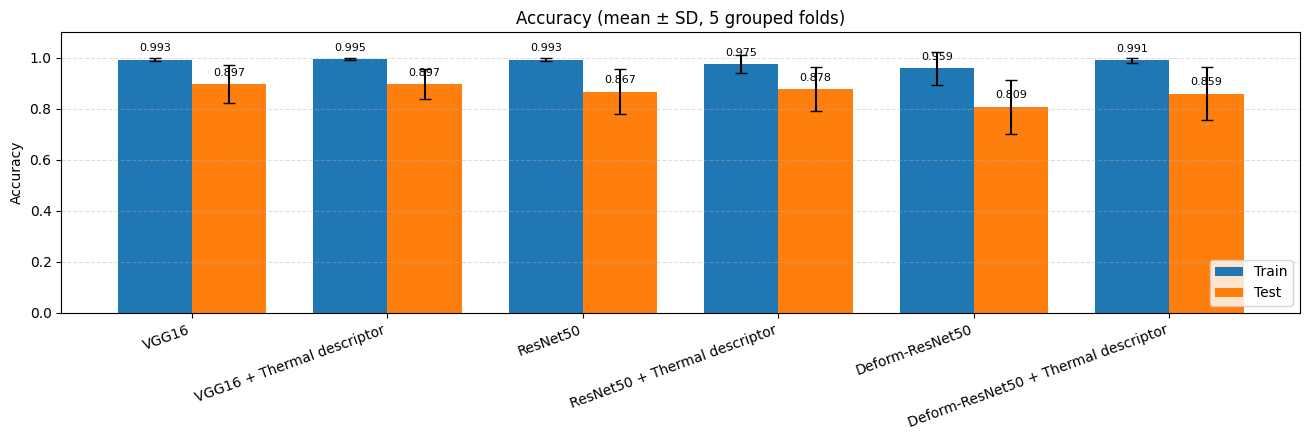

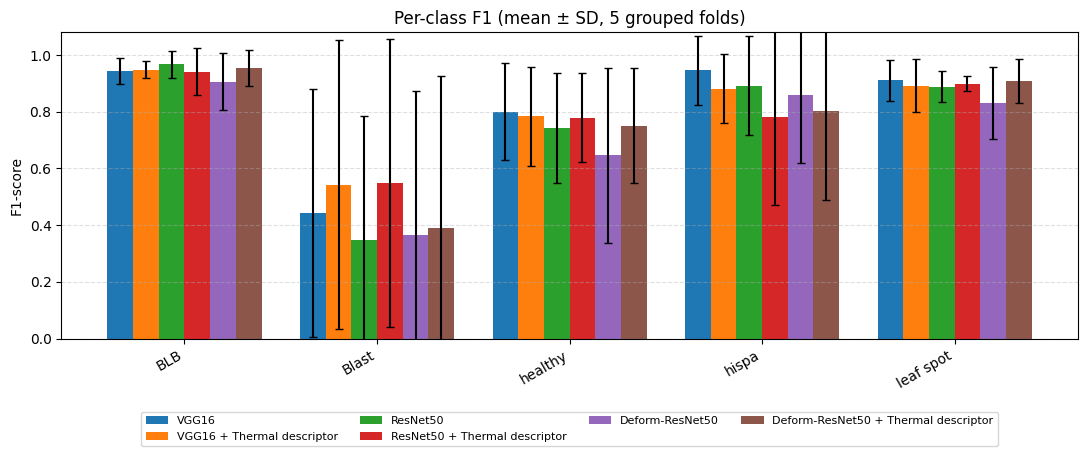

Figures and tables saved in /content/drive/MyDrive/paddy_results/grouped_session_0127


In [35]:
# CELL 11: COMPARISON GRAPHS
# -------------------- COMPARISON FIGURES --------------------
import matplotlib.pyplot as plt
models = [m for m in order if m in set(runs['model'])]
fig, ax = plt.subplots(figsize=(max(6, 2.2 * len(models)), 4.5))
g = runs.groupby('model')
x = np.arange(len(models)); w = 0.38
for k, (col, lab) in enumerate([('train_acc', 'Train'), ('test_acc', 'Test')]):
    mu = [g[col].mean()[m] for m in models]; sd = [g[col].std()[m] if N_FOLDS > 1 else 0 for m in models]
    bars = ax.bar(x + (k - 0.5) * w, mu, w, yerr=sd, capsize=4, label=lab)
    for bb, v in zip(bars, mu):
        ax.annotate(f'{v:.3f}', (bb.get_x() + bb.get_width() / 2, v), xytext=(0, 6),
                    textcoords='offset points', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('Accuracy'); ax.legend(loc='lower right')
ax.set_title(f'Accuracy (mean ± SD, {N_FOLDS} grouped folds)'); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/compare_accuracy.png', dpi=300, bbox_inches='tight'); plt.show()

f1 = pd.DataFrame(f1_rows); f1.to_csv(f'{OUT_DIR}/per_class_f1_all_seeds.csv', index=False)
fs = f1.groupby(['class', 'model'])['F1'].agg(['mean', 'std']).reset_index()
fig, ax = plt.subplots(figsize=(11, 4.8)); w = 0.8 / len(models); x = np.arange(len(class_names))
for k, m in enumerate(models):
    d = fs[fs['model'] == m].set_index('class').reindex(class_names)
    ax.bar(x + (k - (len(models) - 1) / 2) * w, d['mean'], w,
           yerr=d['std'].fillna(0) if N_FOLDS > 1 else None, capsize=3, label=m)
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylim(0, 1.08); ax.set_ylabel('F1-score')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=min(4, len(models)), fontsize=8)
ax.set_title(f'Per-class F1 (mean ± SD, {N_FOLDS} grouped folds)'); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/compare_per_class_f1.png', dpi=300, bbox_inches='tight'); plt.show()
print('Figures and tables saved in', OUT_DIR)


## Cell 12 – DSI (Table 5)
Set `DSI_MODEL` to the model you report.

In [38]:
# CELL 12b: DSI for all models (pooled out-of-fold predictions)
SEVERITY = {'healthy': 0.00, 'leaf spot': 0.50, 'leaf folder': 0.55,
            'hispa': 0.65, 'blb': 0.90, 'blast': 1.00}
MODELS = {'vgg16': 'VGG16', 'vgg16_descriptor': 'VGG16 + TD',
          'resnet50': 'ResNet50', 'resnet50_descriptor': 'ResNet50 + TD',
          'deform_resnet50': 'Deform-ResNet50', 'deform_resnet50_descriptor': 'Deform-ResNet50 + TD'}
rng = np.random.default_rng(42); B = 1000
rows = []
for tag, name in MODELS.items():
    d = np.load(f'{OUT_DIR}/{tag}/predictions.npz', allow_pickle=True)
    y_true, y_prob, cls = d['y_true'], d['y_prob'], [str(c) for c in d['class_names']]
    sigma = y_prob @ np.array([SEVERITY[c.lower()] for c in cls])
    for i, c in enumerate(cls):
        v = sigma[y_true == i]
        lo, hi = np.percentile([rng.choice(v, len(v)).mean() for _ in range(B)], [2.5, 97.5])
        rows.append({'Model': name, 'Class': c, 'DSI': f'{v.mean():.2f} [{lo:.2f}, {hi:.2f}]'})
dsi_all = pd.DataFrame(rows).pivot(index='Class', columns='Model', values='DSI')
dsi_all = dsi_all.loc[['healthy', 'leaf spot', 'hispa', 'Blast', 'BLB'], list(MODELS.values())]
dsi_all.to_csv(f'{OUT_DIR}/table_dsi_all_models.csv')
pd.set_option('display.width', 250); print(dsi_all)

Model                  VGG16         VGG16 + TD           ResNet50      ResNet50 + TD    Deform-ResNet50 Deform-ResNet50 + TD
Class                                                                                                                        
healthy    0.21 [0.18, 0.25]  0.21 [0.17, 0.24]  0.26 [0.22, 0.31]  0.28 [0.24, 0.32]  0.23 [0.19, 0.28]    0.24 [0.20, 0.27]
leaf spot  0.48 [0.46, 0.50]  0.48 [0.46, 0.50]  0.49 [0.47, 0.51]  0.48 [0.46, 0.50]  0.50 [0.48, 0.52]    0.49 [0.47, 0.51]
hispa      0.68 [0.66, 0.70]  0.67 [0.66, 0.69]  0.67 [0.64, 0.69]  0.69 [0.67, 0.72]  0.65 [0.63, 0.67]    0.66 [0.63, 0.70]
Blast      0.73 [0.66, 0.80]  0.75 [0.69, 0.82]  0.67 [0.59, 0.75]  0.79 [0.73, 0.85]  0.60 [0.52, 0.68]    0.64 [0.54, 0.73]
BLB        0.82 [0.80, 0.84]  0.80 [0.78, 0.83]  0.83 [0.81, 0.84]  0.80 [0.78, 0.82]  0.78 [0.75, 0.80]    0.81 [0.79, 0.83]


In [37]:
from scipy.stats import binomtest
a = np.load(f'{OUT_DIR}/resnet50/predictions.npz'); b = np.load(f'{OUT_DIR}/deform_resnet50/predictions.npz')
ca, cb = a['y_prob'].argmax(1) == a['y_true'], b['y_prob'].argmax(1) == b['y_true']
n1, n2 = int(np.sum(ca & ~cb)), int(np.sum(~ca & cb))
print('only ResNet50 right:', n1, '| only Deform right:', n2, '| p =', round(binomtest(n1, n1 + n2).pvalue, 4))

only ResNet50 right: 20 | only Deform right: 3 | p = 0.0005


In [39]:
from sklearn.metrics import precision_recall_fscore_support
MODELS = {'vgg16': 'VGG16', 'vgg16_descriptor': 'VGG16 + TD', 'resnet50': 'ResNet50',
          'resnet50_descriptor': 'ResNet50 + TD', 'deform_resnet50': 'Deform-ResNet50',
          'deform_resnet50_descriptor': 'Deform-ResNet50 + TD'}
rows = []
for tag, name in MODELS.items():
    d = np.load(f'{OUT_DIR}/{tag}/predictions.npz', allow_pickle=True)
    yt, yp, cls = d['y_true'], d['y_prob'].argmax(1), [str(c) for c in d['class_names']]
    p, r, f, s = precision_recall_fscore_support(yt, yp, labels=range(len(cls)), zero_division=0)
    for c, pi, ri, fi in zip(cls, p, r, f):
        rows.append({'Model': name, 'Class': c, 'F1': round(fi, 3)})
f1_pooled = pd.DataFrame(rows).pivot(index='Class', columns='Model', values='F1')[list(MODELS.values())]
f1_pooled.to_csv(f'{OUT_DIR}/per_class_f1_pooled.csv'); print(f1_pooled)

Model      VGG16  VGG16 + TD  ResNet50  ResNet50 + TD  Deform-ResNet50  Deform-ResNet50 + TD
Class                                                                                       
BLB        0.944       0.948     0.965          0.939            0.912                 0.950
Blast      0.817       0.868     0.686          0.829            0.609                 0.687
healthy    0.899       0.890     0.832          0.867            0.788                 0.839
hispa      0.936       0.875     0.889          0.791            0.864                 0.818
leaf spot  0.906       0.893     0.887          0.898            0.826                 0.903


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['image']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


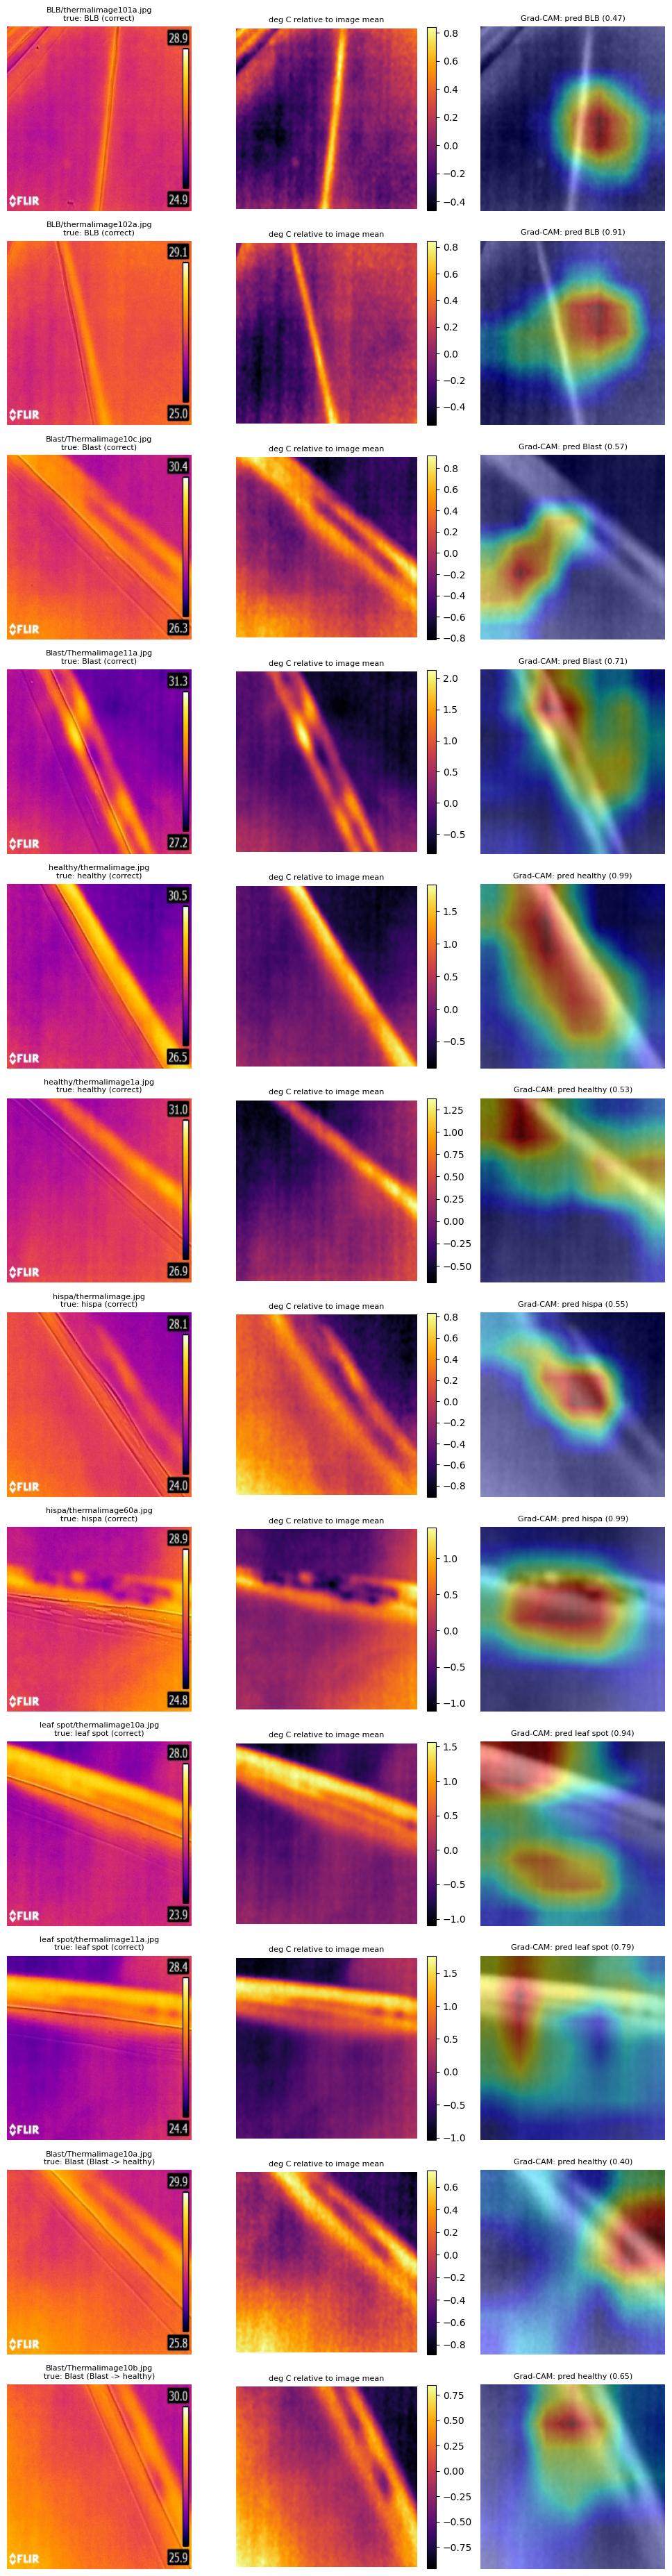

Saved /content/drive/MyDrive/paddy_results/grouped_session_0127/vgg16/gradcam_examples.png


In [12]:
# CELL 16: GRAD-CAM for VGG16 (each image explained by the fold model that never saw its leaf)
# Requires cells 1-8 and the saved fold weights in _resume/vgg16_fold*/stage2/best.weights.h5
CAM_TAG, N_PER_CLASS = 'vgg16', 2
v = np.load(f'{OUT_DIR}/{CAM_TAG}/predictions.npz'); oof_pred = v['y_prob'].argmax(1)
fold_of = np.empty(len(y_int), int)
for k, (_, _, te_i) in enumerate(FOLDS): fold_of[te_i] = k
picks = []                                                     # correct examples per class
for c in range(len(class_names)):
    ok = np.where((y_int == c) & (oof_pred == c))[0]
    seen = set()
    for i in ok:                                               # one shot per leaf group
        if groups[i] not in seen and len(seen) < N_PER_CLASS:
            seen.add(groups[i]); picks.append((i, 'correct'))
bi, hi = class_names.index('Blast'), class_names.index('healthy')
picks += [(i, 'Blast -> healthy') for i in np.where((y_int == bi) & (oof_pred == hi))[0][:2]]

_models = {}
def fold_model(k):
    if k not in _models:
        w = f'{STATE_ROOT}/{CAM_TAG}_fold{k}/stage2/best.weights.h5'
        assert os.path.exists(w), f'missing fold weights: {w}'
        tf.keras.backend.clear_session() if not _models else None
        m, _, prep_k, _ = build_model('vgg16', 'none'); m.load_weights(w)
        _models[k] = (Model(m.inputs, [m.get_layer('conv3x3').output, m.output]), prep_k)
    return _models[k]

def grad_cam(i):
    gm, prep_k = fold_model(fold_of[i])
    x = prep_k(X[i:i + 1].copy())
    with tf.GradientTape() as tape:
        fmap, out = gm(x, training=False)
        score = out[:, int(oof_pred[i])]
    g = tape.gradient(score, fmap)
    w = tf.reduce_mean(g, axis=(1, 2))                          # Eq. (5): alpha_m
    cam = tf.nn.relu(tf.reduce_sum(fmap[0] * w[0], axis=-1)).numpy()
    cam = cv2.resize(cam / (cam.max() + 1e-8), IMG_SIZE)
    return cam, float(np.asarray(out)[0, int(oof_pred[i])])

n = len(picks)
assert n, 'no examples to plot'
fig, axs = plt.subplots(n, 3, figsize=(10, 3.1 * n), squeeze=False)
for r, (i, kind) in enumerate(picks):
    cam, conf = grad_cam(i)
    axs[r, 0].imshow(X[i].astype(np.uint8)); axs[r, 0].set_title(f'{paths[i]}\ntrue: {class_names[y_int[i]]} ({kind})', fontsize=8)
    im = axs[r, 1].imshow(TM[i, ..., 0], cmap='inferno'); axs[r, 1].set_title('deg C relative to image mean', fontsize=8)
    plt.colorbar(im, ax=axs[r, 1], fraction=0.046)
    axs[r, 2].imshow(TM[i, ..., 0], cmap='gray'); axs[r, 2].imshow(cam, cmap='jet', alpha=0.45)
    axs[r, 2].set_title(f'Grad-CAM: pred {class_names[oof_pred[i]]} ({conf:.2f})', fontsize=8)
    for a in axs[r]: a.axis('off')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/{CAM_TAG}/gradcam_examples.png', dpi=200, bbox_inches='tight'); plt.show()
print('Saved', f'{OUT_DIR}/{CAM_TAG}/gradcam_examples.png')

Palette learned from 50 images, tested on 51 unseen leaves
         MAE    PSNR   SSIM
mean  14.719  24.233  0.727
std   10.853   4.695  0.030
min    4.764  12.410  0.627
max   54.661  31.516  0.785


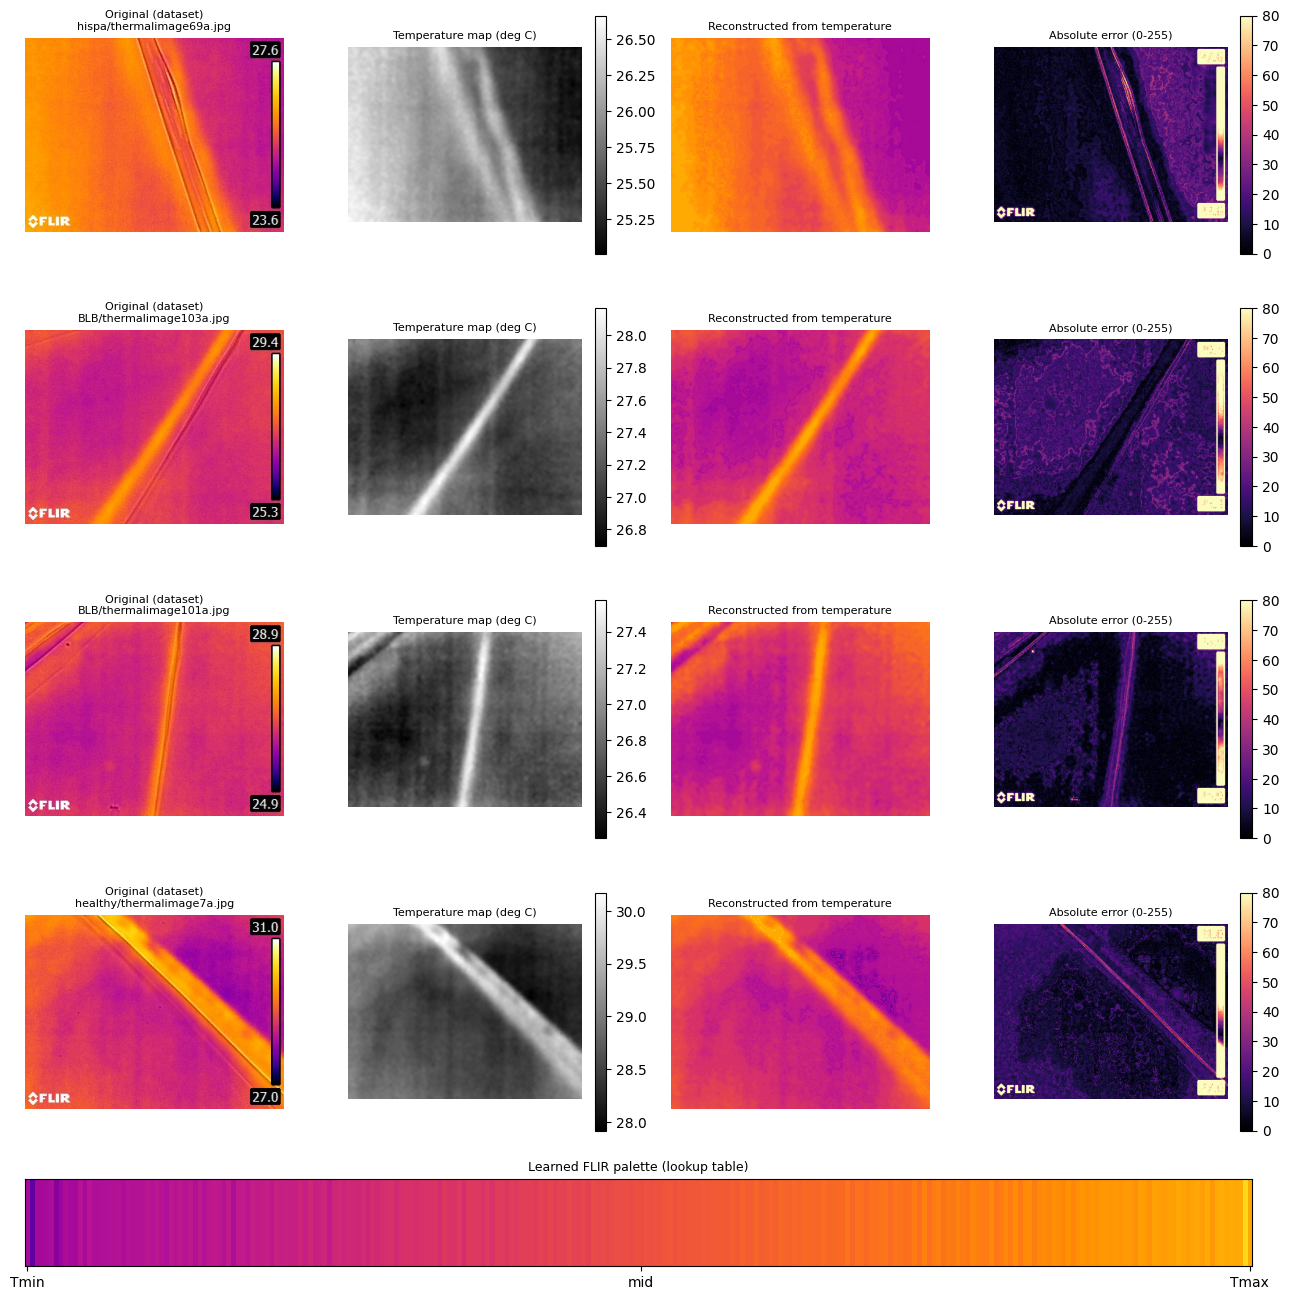

In [13]:
# CELL 18: RECONSTRUCT THE FLIR FALSE-COLOUR IMAGE FROM THE TEMPERATURE MAP (T -> RGB)
# Requires cells 1-8 (DATA_ROOT, maps, map_key, paths). The camera renders each image as
#   v = (T - Tmin) / (Tmax - Tmin)  ->  palette lookup table (LUT)  ->  RGB  (+ MSX edges + overlays)
# We LEARN the palette LUT from half of the images and test the reconstruction on the other half.
import glob
from skimage.metrics import structural_similarity as ssim
N_BINS = 256

def find_jpg(p):                                   # 'BLB/thermalimage101a.jpg' -> full path
    hits = glob.glob(os.path.join(DATA_ROOT, '*', p))
    return hits[0] if hits else None

def overlay_mask(H, W):                            # True = usable pixel (no scale bar / logo)
    m = np.ones((H, W), bool)
    m[:, int(.86 * W):] = False                    # temperature scale bar + numbers (right)
    m[int(.86 * H):, :int(.28 * W)] = False        # FLIR logo (bottom left)
    return m

def load_pair(p):
    T = maps[map_key[p]].astype(np.float32)        # radiometric deg C, (240, 320)
    bgr = cv2.imread(find_jpg(p))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if rgb.shape[:2] != T.shape:
        rgb = cv2.resize(rgb, (T.shape[1], T.shape[0]), interpolation=cv2.INTER_AREA)
    return T, rgb

def normalise(T, m):                               # per-image auto-range, as the camera does
    lo, hi = np.percentile(T[m], [0.5, 99.5])
    return np.clip((T - lo) / (hi - lo + 1e-6), 0, 1)

# ---- 1. learn the palette LUT on half of the images (one image per leaf group) ----
rng = np.random.default_rng(0)
uniq = pd.Series(np.arange(len(paths))).groupby(groups).first().to_numpy().copy()   # one shot per leaf
rng.shuffle(uniq)
fit_idx, test_idx = uniq[: len(uniq) // 2], uniq[len(uniq) // 2:]
acc = [[] for _ in range(N_BINS)]
for i in fit_idx:
    T, rgb = load_pair(paths[i]); m = overlay_mask(*T.shape)
    b = (normalise(T, m) * (N_BINS - 1)).round().astype(int)
    for k in range(N_BINS):
        sel = m & (b == k)
        if sel.any(): acc[k].append(rgb[sel][::5])
LUT = np.zeros((N_BINS, 3), np.float32); have = np.zeros(N_BINS, bool)
for k in range(N_BINS):
    if acc[k]:
        LUT[k] = np.median(np.concatenate(acc[k]), axis=0); have[k] = True
for c in range(3):                                 # fill empty bins by interpolation
    LUT[~have, c] = np.interp(np.where(~have)[0], np.where(have)[0], LUT[have, c])
np.save(f'{OUT_DIR}/flir_palette_lut.npy', LUT)

def thermal_to_flir_rgb(T, m=None):
    m = overlay_mask(*T.shape) if m is None else m
    b = (normalise(T, m) * (N_BINS - 1)).round().astype(int)
    return LUT[b].astype(np.uint8)

# ---- 2. evaluate on the held-out images (masked: overlays excluded) ----
rows = []
for i in test_idx:
    T, rgb = load_pair(paths[i]); m = overlay_mask(*T.shape)
    rec = thermal_to_flir_rgb(T, m)
    diff = np.abs(rgb.astype(float) - rec.astype(float))[m]
    mse = np.mean(diff ** 2)
    g1 = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY); g2 = cv2.cvtColor(rec, cv2.COLOR_RGB2GRAY)
    rows.append({'file': paths[i], 'MAE': diff.mean(), 'PSNR': 10 * np.log10(255 ** 2 / mse),
                 'SSIM': ssim(g1, g2, data_range=255)})
ev = pd.DataFrame(rows); ev.to_csv(f'{OUT_DIR}/reconstruction_eval.csv', index=False)
print(f'Palette learned from {len(fit_idx)} images, tested on {len(test_idx)} unseen leaves')
print(ev[['MAE', 'PSNR', 'SSIM']].describe().loc[['mean', 'std', 'min', 'max']].round(3))

# ---- 3. figure: original | temperature | reconstructed | error ----
show = test_idx[:4]
fig, axs = plt.subplots(len(show) + 1, 4, figsize=(13, 3.0 * len(show) + 1.2),
                        gridspec_kw={'height_ratios': [1] * len(show) + [0.35]})
for r, i in enumerate(show):
    T, rgb = load_pair(paths[i]); rec = thermal_to_flir_rgb(T)
    axs[r, 0].imshow(rgb); axs[r, 0].set_title(f'Original (dataset)\n{paths[i]}', fontsize=8)
    im = axs[r, 1].imshow(T, cmap='gray'); axs[r, 1].set_title('Temperature map (deg C)', fontsize=8)
    plt.colorbar(im, ax=axs[r, 1], fraction=0.046)
    axs[r, 2].imshow(rec); axs[r, 2].set_title('Reconstructed from temperature', fontsize=8)
    e = np.abs(rgb.astype(float) - rec.astype(float)).mean(-1)
    im2 = axs[r, 3].imshow(e, cmap='magma', vmin=0, vmax=80); axs[r, 3].set_title('Absolute error (0-255)', fontsize=8)
    plt.colorbar(im2, ax=axs[r, 3], fraction=0.046)
    for a in axs[r]: a.axis('off')
gs = axs[-1, 0].get_gridspec()
for a in axs[-1]: a.remove()
axl = fig.add_subplot(gs[-1, :]); axl.imshow(LUT[None].astype(np.uint8), aspect='auto')
axl.set_yticks([]); axl.set_xticks([0, 128, 255]); axl.set_xticklabels(['Tmin', 'mid', 'Tmax'])
axl.set_title('Learned FLIR palette (lookup table)', fontsize=9)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/thermal_to_rgb_reconstruction.png', dpi=200, bbox_inches='tight'); plt.show()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['image']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


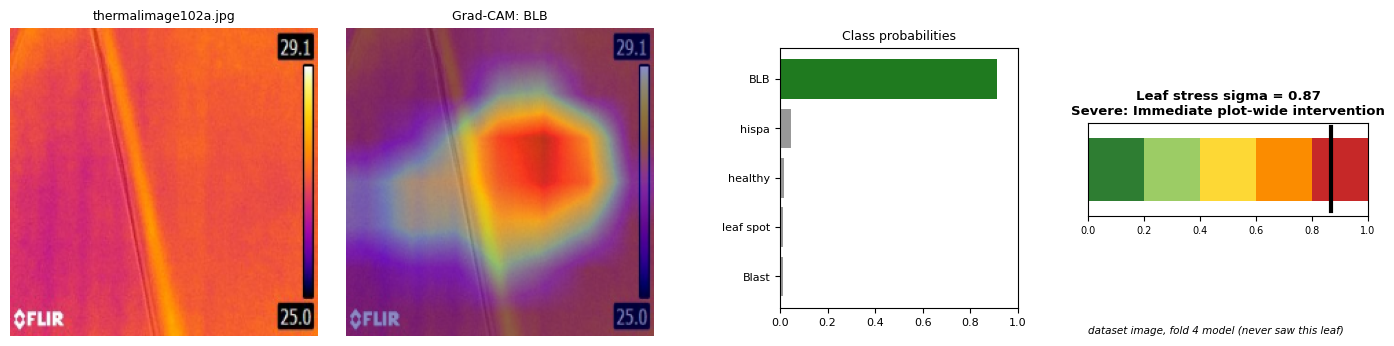

{'file': '/content/paddy_diseases/thermal images UL/BLB/thermalimage102a.jpg', 'predicted': 'BLB', 'probabilities': {'BLB': 0.911, 'Blast': 0.012, 'healthy': 0.018, 'hispa': 0.046, 'leaf spot': 0.013}, 'sigma': 0.868, 'band': 'Severe', 'action': 'Immediate plot-wide intervention', 'mode': 'dataset image, fold 4 model (never saw this leaf)'}


In [11]:
# CELL 19: DSI FOR ONE LEAF IMAGE  (prediction + Grad-CAM + per-leaf stress sigma + management band)
# Requires cells 1-8 (models, folds, IMG_SIZE, STATE_ROOT). Uses the trained VGG16 fold models.
#  - image FROM THIS DATASET  -> only the fold model that never saw that leaf is used (no leakage)
#  - NEW image (any path)     -> average of the 5 fold models (ensemble)
import glob
SEVERITY = {'healthy': 0.00, 'leaf spot': 0.50, 'leaf folder': 0.55,
            'hispa': 0.65, 'blb': 0.90, 'blast': 1.00}
BANDS = [(0.0, 0.2, 'Negligible', 'Routine monitoring', '#2e7d32'), (0.2, 0.4, 'Low', 'Increased scouting', '#9ccc65'),
         (0.4, 0.6, 'Moderate', 'Targeted inspection', '#fdd835'), (0.6, 0.8, 'High', 'Localised treatment', '#fb8c00'),
         (0.8, 1.01, 'Severe', 'Immediate plot-wide intervention', '#c62828')]
W_SEV = np.array([SEVERITY[c.lower()] for c in class_names])
_leaf_models = {}

def _fold_cam_model(k):
    if k not in _leaf_models:
        w = f'{STATE_ROOT}/vgg16_fold{k}/stage2/best.weights.h5'
        assert os.path.exists(w), f'missing fold weights: {w}'
        m, _, prep_k, _ = build_model('vgg16', 'none'); m.load_weights(w)
        _leaf_models[k] = (Model(m.inputs, [m.get_layer('conv3x3').output, m.output]), prep_k)
    return _leaf_models[k]

def leaf_dsi(image_path, show=True, save_to=None):
    bgr = cv2.imread(image_path); assert bgr is not None, f'cannot read {image_path}'
    img = cv2.cvtColor(cv2.resize(bgr, IMG_SIZE), cv2.COLOR_BGR2RGB).astype(np.float32)
    rel = os.path.join(os.path.basename(os.path.dirname(image_path)), os.path.basename(image_path))
    in_data = rel in set(paths)
    if in_data:                                              # out-of-fold model only
        i = int(np.where(paths == rel)[0][0])
        folds = [k for k, (_, _, te) in enumerate(FOLDS) if i in set(te)]
        mode = f'dataset image, fold {folds[0]} model (never saw this leaf)'
    else:
        folds = list(range(len(FOLDS))); mode = f'new image, ensemble of {len(folds)} fold models'
    probs, cams = [], []
    for k in folds:
        gm, prep_k = _fold_cam_model(k)
        x = prep_k(img[None].copy())
        with tf.GradientTape() as tape:
            fmap, out = gm(x, training=False)
            top = int(np.argmax(out[0])); score = out[:, top]
        g = tape.gradient(score, fmap)
        cam = tf.nn.relu(tf.reduce_sum(fmap[0] * tf.reduce_mean(g, axis=(1, 2))[0], axis=-1)).numpy()
        cams.append(cv2.resize(cam / (cam.max() + 1e-8), IMG_SIZE)); probs.append(np.asarray(out[0]))
    p = np.mean(probs, axis=0); cam = np.mean(cams, axis=0)
    sigma = float(p @ W_SEV)                                 # Eq. (6): per-leaf stress
    band = next(b for b in BANDS if b[0] <= sigma < b[1])
    pred = class_names[int(np.argmax(p))]
    if show or save_to:
        fig = plt.figure(figsize=(14, 4.2))
        a1 = fig.add_axes([0.01, 0.08, 0.22, 0.8]); a1.imshow(img.astype(np.uint8)); a1.axis('off')
        a1.set_title(os.path.basename(image_path), fontsize=9)
        a2 = fig.add_axes([0.25, 0.08, 0.22, 0.8]); a2.imshow(img.astype(np.uint8)); a2.imshow(cam, cmap='jet', alpha=0.45)
        a2.axis('off'); a2.set_title(f'Grad-CAM: {pred}', fontsize=9)
        a3 = fig.add_axes([0.56, 0.18, 0.17, 0.62]); o = np.argsort(p)
        a3.barh(np.array(class_names)[o], p[o], color=['#1f7a1f' if class_names[j] == pred else '#999' for j in o])
        a3.set_xlim(0, 1); a3.set_title('Class probabilities', fontsize=9); a3.tick_params(labelsize=8)
        a4 = fig.add_axes([0.78, 0.40, 0.2, 0.22])
        for lo, hi, nm, _, col in BANDS: a4.barh(0, min(hi, 1) - lo, left=lo, color=col, height=0.6)
        a4.plot([sigma, sigma], [-0.4, 0.4], 'k', lw=3); a4.set_xlim(0, 1); a4.set_yticks([]); a4.tick_params(labelsize=7)
        a4.set_title(f'Leaf stress sigma = {sigma:.2f}\n{band[2]}: {band[3]}', fontsize=9.5, weight='bold')
        fig.text(0.78, 0.12, mode, fontsize=7.5, style='italic')
        if save_to: fig.savefig(save_to, dpi=200, bbox_inches='tight')
        plt.show() if show else plt.close(fig)
    return {'file': image_path, 'predicted': pred, 'probabilities': {c: round(float(v), 3) for c, v in zip(class_names, p)},
            'sigma': round(sigma, 3), 'band': band[2], 'action': band[3], 'mode': mode}

# ---- example: one leaf from the dataset (uses its out-of-fold model) ----
example = glob.glob(os.path.join(DATA_ROOT, '*', 'BLB', 'thermalimage102a.jpg'))
if example:
    print(leaf_dsi(example[0], save_to=f'{OUT_DIR}/leaf_dsi_example.png'))
# ---- your own image ----
# print(leaf_dsi('/content/drive/MyDrive/my_leaf.jpg'))
# ---- a whole folder = one plot: plot DSI = mean of the leaf sigmas (Eq. 7) ----
# res = [leaf_dsi(f, show=False) for f in sorted(glob.glob('/content/drive/MyDrive/plot_A/*.jpg'))]
# print('Plot DSI =', round(np.mean([r['sigma'] for r in res]), 3))